# **Código Final Excedencias sobre la norma**

Integrantes del equipo:
* José Miguel del Hoyo Peña - A00838767
* Juan Pablo Valdés Cárdenas - A00839013
* Julio César Briones Wong - A00838831
* Miguel Cantú Elizondo - A00838990



---


**Comprensión de los datos**


---





En esta sección se importan los datos.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

In [ ]:
data = pd.read_csv('../datos/datos_20_25.csv')
data.head()

,date,CO,NO,NO2,NOX,O3,PM10,PM2.5,PRS,RAINF,RH,SO2,SR,TOUT,WSR,WDR,region
0,2020-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,66.0,54.23,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,SURESTE
1,2020-01-01 01:00:00,2.11,NaN,NaN,NaN,19.0,57.0,NaN,735.7,0.0,96.0,5.4,0.01,11.20,8.1,NaN,SURESTE
2,2020-01-01 02:00:00,2.06,NaN,NaN,NaN,19.0,68.0,53.84,734.8,0.0,96.0,5.5,0.01,11.26,5.5,NaN,SURESTE
3,2020-01-01 03:00:00,1.96,NaN,NaN,NaN,19.0,68.0,36.47,734.2,0.0,96.0,5.4,0.01,11.35,3.8,NaN,SURESTE
4,2020-01-01 04:00:00,1.98,NaN,NaN,NaN,16.0,48.0,33.59,733.9,0.0,96.0,5.5,0.01,11.47,3.3,NaN,SURESTE


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648011 entries, 0 to 648010
Data columns (total 17 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    648011 non-null  object 
 1   CO      553938 non-null  float64
 2   NO      523140 non-null  float64
 3   NO2     518142 non-null  float64
 4   NOX     523881 non-null  float64
 5   O3      539411 non-null  float64
 6   PM10    612090 non-null  float64
 7   PM2.5   482398 non-null  float64
 8   PRS     607950 non-null  float64
 9   RAINF   608962 non-null  float64
 10  RH      575557 non-null  float64
 11  SO2     534737 non-null  float64
 12  SR      619378 non-null  float64
 13  TOUT    597736 non-null  float64
 14  WSR     592690 non-null  float64
 15  WDR     581307 non-null  float64
 16  region  648011 non-null  object 
dtypes: float64(15), object(2)
memory usage: 84.0+ MB


Quitar las variables que no son de nuestro interés: todas las regiones que no sean Sureste seran eliminadas y tambien se eliminaran los quimicos que no se prodizcan de la refinieria de cadereyta.

In [ ]:
# Lista correcta de regiones a conservar
regiones_keep = ["SURESTE3", "SURESTE2", "NORTE2", "NOROESTE2"]

# Dropear todo lo que no esté en la lista
data_clean = data[data['region'].isin(regiones_keep)].copy()

In [ ]:
# columnas que se quitaran
cols_to_drop = ['PRS', 'RAINF', 'RH', 'SR', 'TOUT', 'WSR', 'WDR']
data_clean = data_clean.drop(columns=cols_to_drop)



---


**Nuevo data set**


---



Notar la existencia de datos nulos NaN.

In [ ]:
data_clean

,date,CO,NO,NO2,NOX,O3,PM10,PM2.5,SO2,region
87683,2020-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,92.0,86.93,NaN,NOROESTE2
87684,2020-01-01 01:00:00,1.69,NaN,NaN,NaN,NaN,54.0,NaN,NaN,NOROESTE2
87685,2020-01-01 02:00:00,1.55,NaN,NaN,NaN,NaN,84.0,71.93,NaN,NOROESTE2
87686,2020-01-01 03:00:00,1.50,NaN,NaN,NaN,NaN,NaN,64.91,NaN,NOROESTE2
87687,2020-01-01 04:00:00,1.47,NaN,NaN,NaN,NaN,52.0,NaN,NaN,NOROESTE2
...,...,...,...,...,...,...,...,...,...,...
630680,2025-06-30 19:00:00,0.78,5.8,13.4,19.1,13.0,20.0,NaN,2.9,NORTE2
630681,2025-06-30 20:00:00,0.80,6.1,14.2,20.3,11.0,20.0,7.00,3.6,NORTE2
630682,2025-06-30 21:00:00,0.75,5.6,13.4,18.4,12.0,18.0,8.00,2.5,NORTE2
630683,2025-06-30 22:00:00,0.72,5.0,12.8,17.7,14.0,15.0,7.00,2.3,NORTE2




---



In [ ]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 179661 entries, 87683 to 630684
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    179661 non-null  object 
 1   CO      159374 non-null  float64
 2   NO      152330 non-null  float64
 3   NO2     150161 non-null  float64
 4   NOX     153223 non-null  float64
 5   O3      148961 non-null  float64
 6   PM10    172357 non-null  float64
 7   PM2.5   154497 non-null  float64
 8   SO2     155121 non-null  float64
 9   region  179661 non-null  object 
dtypes: float64(8), object(2)
memory usage: 15.1+ MB


Variables cuantitativas y categóricas del dataset. Las cuantitativas representan las concentraciones por hora de los contaminantes mientras que las cualitativas nos indican la fecha y hora del registro y la región donde se registró.

In [ ]:
# Variables cuantitativas (numéricas)
var_cuantitativas = data_clean.select_dtypes(include=[np.number]).columns.tolist()

# Variables cualitativas (categóricas / objetos)
vas_cualitativas = data_clean.select_dtypes(exclude=[np.number]).columns.tolist()

print("Variables Cuantitativas / Numéricas:", var_cuantitativas)
print("\nVariables Cualitativas / Categóricas :", vas_cualitativas)

Variables Cuantitativas / Numéricas: ['CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'SO2']

Variables Cualitativas / Categóricas : ['date', 'region']




---


**Exploración de datos**


---



In [ ]:
# Seleccion de variables
numeric_cols = data_clean.select_dtypes(include=[np.number])

# Promedio
mean_values = numeric_cols.mean()

# Mediana
median_values = numeric_cols.median()

# Moda
mode_values = numeric_cols.mode().iloc[0]

print("Promedio:\n", mean_values)
print("\nMediana:\n", median_values)
print("\nModa:\n", mode_values)


Promedio:
 CO        1.315188
NO       15.307255
NO2      13.932210
NOX      28.756492
O3       26.156775
PM10     64.666120
PM2.5    21.420881
SO2       5.753867
dtype: float64

Mediana:
 CO        1.21
NO        5.20
NO2      10.10
NOX      17.00
O3       22.00
PM10     55.00
PM2.5    18.00
SO2       4.10
dtype: float64

Moda:
 CO        0.99
NO        2.70
NO2       0.60
NOX       7.20
O3       17.00
PM10     46.00
PM2.5    12.00
SO2       3.40
Name: 0, dtype: float64


In [ ]:
# Seleccion de variables numéricas
numeric_cols = data_clean.select_dtypes(include=[np.number])

# Rango
range_values = numeric_cols.max() - numeric_cols.min()

# Varianza
variance_values = numeric_cols.var()

# Desviación estándar
std_values = numeric_cols.std()

dispersion_df = pd.DataFrame({
    'Rango': range_values,
    'Varianza': variance_values,
    'Desviación Estandar': std_values
})

dispersion_df

,Rango,Varianza,Desviación Estandar
CO,22.51,0.579905,0.761515
NO,499.50,800.129685,28.286564
NO2,188.60,156.317707,12.502708
NOX,499.50,1185.699464,34.433987
O3,274.00,324.540379,18.015004
PM10,962.00,1896.209011,43.545482
PM2.5,484.00,269.740865,16.423790
SO2,404.20,44.066619,6.638269


In [ ]:
# Distribución de frecuencias para las regiones
freq_region = pd.DataFrame({
    'Frecuencia Absoluta': data_clean['region'].value_counts(),
    'Frecuencia Relativa (%)': data_clean['region'].value_counts(normalize=True) * 100
})

# Convertimos 'date' a datetime
data_clean['date'] = pd.to_datetime(data_clean['date'], errors='coerce')

# Frecuencias por año
freq_date = pd.DataFrame({
    'Frecuencia Absoluta': data_clean['date'].dt.year.value_counts().sort_index(),
    'Frecuencia Relativa (%)': data_clean['date'].dt.year.value_counts(normalize=True).sort_index() * 100
})

print("Distribución de frecuencia - REGION")
display(freq_region)

print("\nDistribución de frecuencia - DATE (por año)")
display(freq_date)


Distribución de frecuencia - REGION


,Frecuencia Absoluta,Frecuencia Relativa (%)
region,,
SURESTE2,44916,25.000417
NOROESTE2,44915,24.999861
SURESTE3,44915,24.999861
NORTE2,44915,24.999861



Distribución de frecuencia - DATE (por año)


,Frecuencia Absoluta,Frecuencia Relativa (%)
date,,
2020,35104,19.539021
2021,35037,19.501728
2022,35040,19.503398
2023,21980,12.234152
2024,35128,19.552379
2025,17372,9.669322




---

**Explora los datos usando herramientas de visualización**


---




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Seleccionar solo variables numéricas
numeric = data_clean.select_dtypes(include='number')

# Calcular cuartiles e IQR
Q1 = numeric.quantile(0.25)
Q2 = numeric.quantile(0.50)
Q3 = numeric.quantile(0.75)
IQR = Q3 - Q1

# Outliers con regla 1.5*IQR
outliers = ((numeric < (Q1 - 1.5*IQR)) | (numeric > (Q3 + 1.5*IQR))).sum()

# Tabla resumen
cuartiles_df = pd.DataFrame({
    "Q1": Q1,
    "Q2 (Mediana)": Q2,
    "Q3": Q3,
    "IQR": IQR,
    "Outliers": outliers
}).round(2)

display(cuartiles_df)

,Q1,Q2 (Mediana),Q3,IQR,Outliers
CO,0.79,1.21,1.7,0.91,3851
NO,3.30,5.20,13.9,10.60,22701
NO2,5.40,10.10,18.9,13.50,7003
NOX,9.70,17.00,34.4,24.70,12799
O3,13.00,22.00,35.0,22.00,4320
PM10,39.00,55.00,78.0,39.00,9044
PM2.5,10.97,18.00,28.0,17.03,5962
SO2,3.10,4.10,5.9,2.80,15714


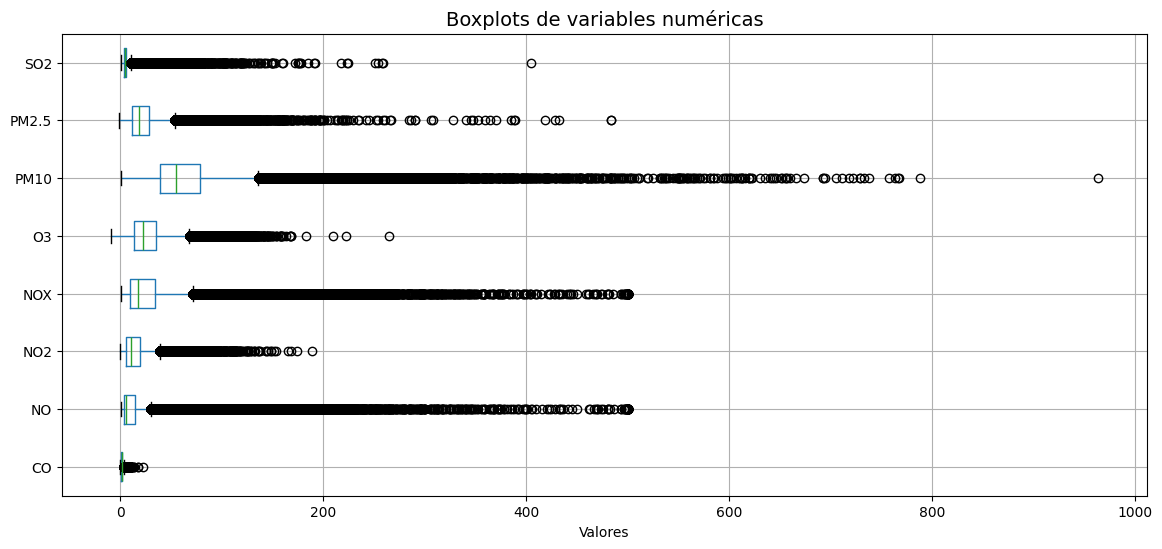

In [ ]:
plt.figure(figsize=(14,6))
numeric.boxplot(vert=False)
plt.title("Boxplots de variables numéricas", fontsize=14)
plt.xlabel("Valores")
plt.show()

**Analisis:**

* CO y SO2: tienen valores bajos en la mayoría de los casos, pero con algunos  picos extremos que se salen mucho de la caja.
* NO, NO2 y NOX: concentran la mayor parte de los datos en valores cercanos a cero, pero con muchos registros anómalos en valores muy altos.
* O3: presenta también asimetría positiva, aunque con menos dispersión en comparación a NO y NO2.
* PM10 y PM2.5: se observa una dispersión mayor, con muchos outliers que se alejan hasta valores muy altos, lo que refleja episodios de contaminación puntual.

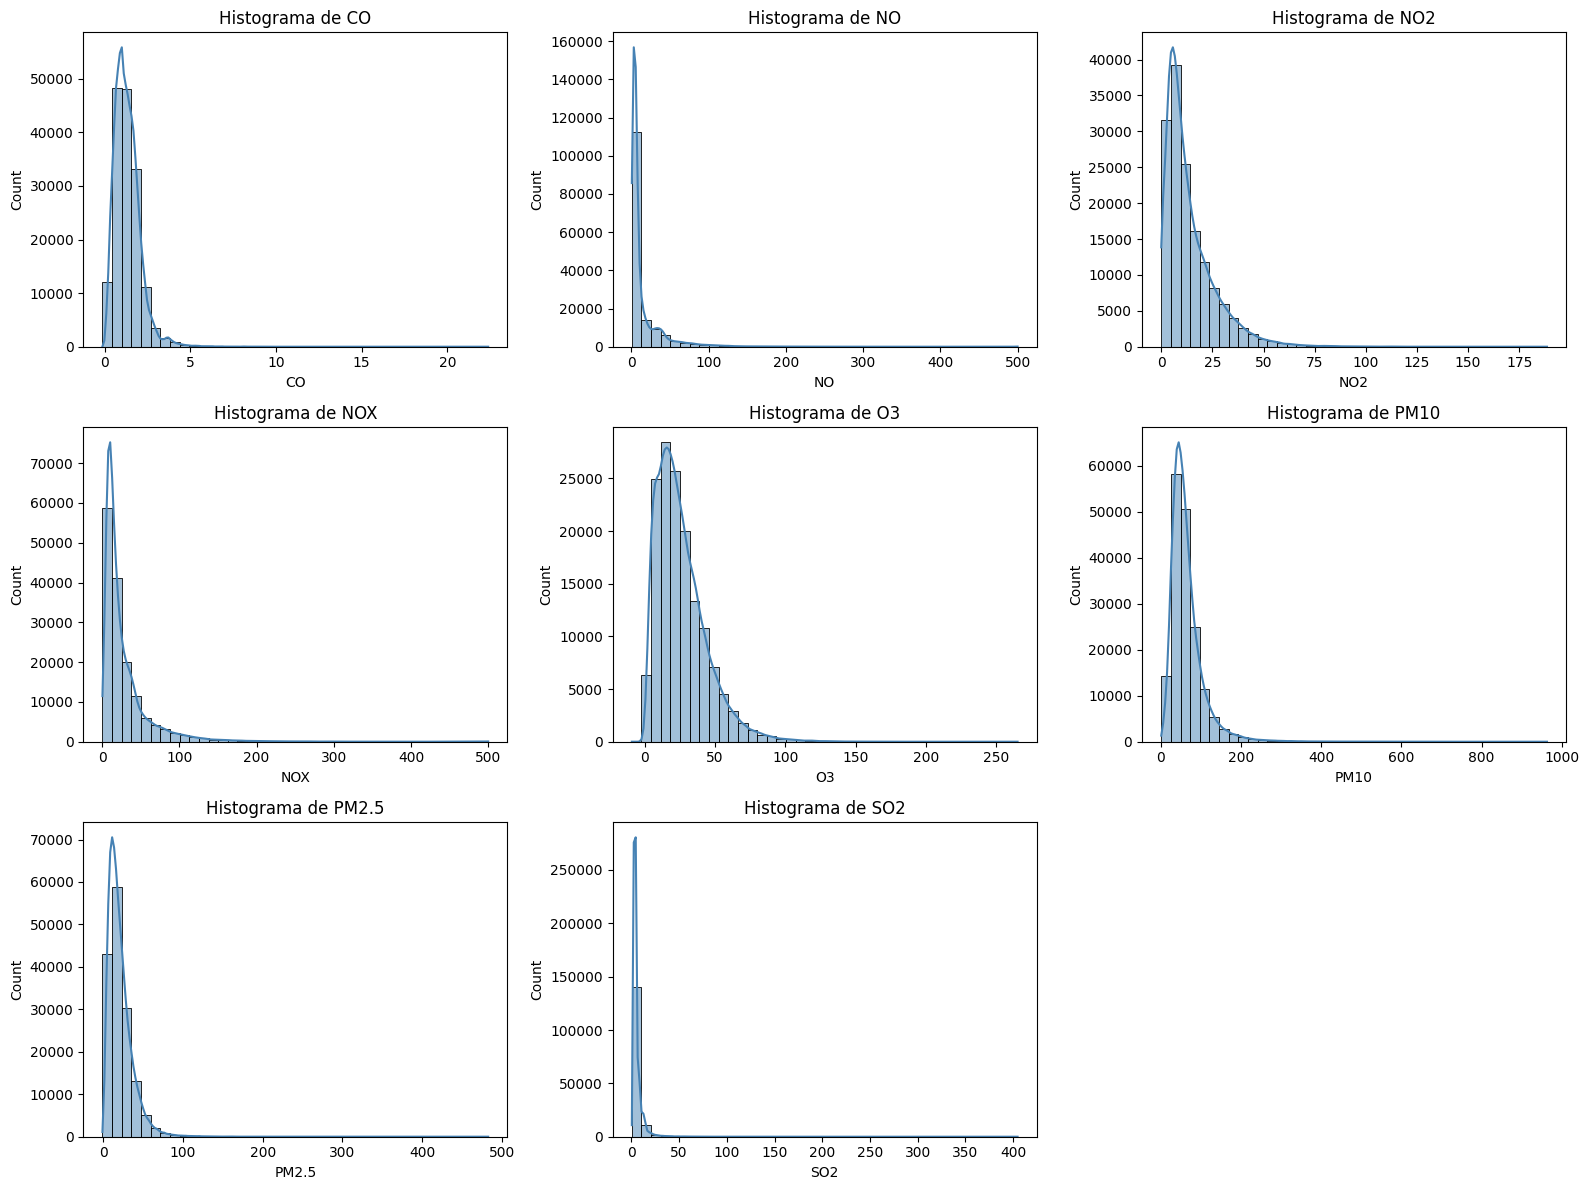

In [ ]:
# Histogramas de contaminantes
import seaborn as sns

numeric_cols = data_clean.select_dtypes(include='number').columns

plt.figure(figsize=(16, 12))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data_clean[col].dropna(), kde=True, bins=40, color="steelblue")
    plt.title(f"Histograma de {col}")

plt.tight_layout()
plt.show()

Matriz de correlación para observar posibles relaciones entre variables.

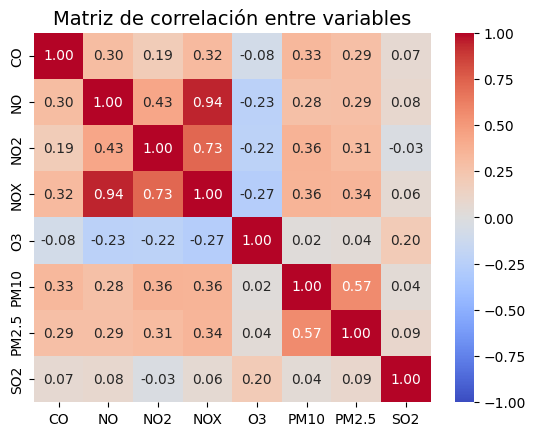

In [ ]:
# Correlación de variables
corr_matrix = data_clean.select_dtypes(include=[np.number]).corr()

# Mapa de calor con escala -1 a 1
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)

plt.title("Matriz de correlación entre variables", fontsize=14)
plt.show()


/tmp/ipython-input-1195832587.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_region.index, y=freq_region.values, palette="viridis")


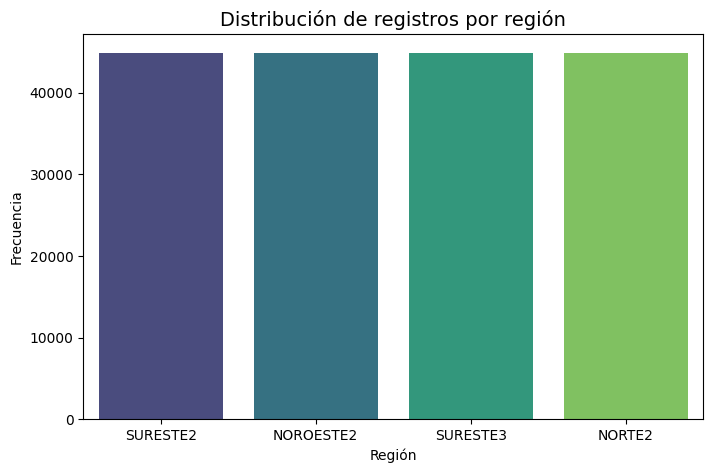

In [ ]:
freq_region = data_clean['region'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=freq_region.index, y=freq_region.values, palette="viridis")
plt.title("Distribución de registros por región", fontsize=14)
plt.xlabel("Región")
plt.ylabel("Frecuencia")
plt.show()

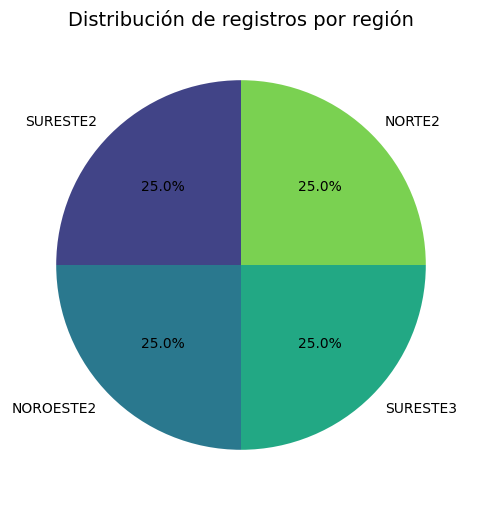

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(freq_region.values, labels=freq_region.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("viridis", len(freq_region)))
plt.title("Distribución de registros por región", fontsize=14)
plt.show()



---


**Verifica la calidad de los datos**


---



Datos nulos.

In [ ]:
# Cantidad de datos que son nulos
display(data_clean.isna().sum())

,0
date,0
CO,20287
NO,27331
NO2,29500
NOX,26438
O3,30700
PM10,7304
PM2.5,25164
SO2,24540
region,0


Datos duplicados.

In [ ]:
data_clean.duplicated().sum()

np.int64(0)

Datos negativos (error, no pueden ser negativos dada la naturaleza de lo que se está registrando)

In [ ]:
numeric_cols = data_clean.select_dtypes(include="number").columns

errores = {}
for col in numeric_cols:
    errores[col] = (data_clean[col] < 0).sum()

errores_df = pd.DataFrame.from_dict(errores, orient='index', columns=['Valores Negativos'])
display(errores_df[errores_df['Valores Negativos'] > 0])


,Valores Negativos
CO,1
O3,1
PM2.5,1


In [ ]:
promedios = data_clean.select_dtypes(include='number').mean()

promedios_df = promedios.reset_index()
promedios_df.columns = ['Variable', 'Promedio']

display(promedios_df.round(2))

,Variable,Promedio
0,CO,1.32
1,NO,15.31
2,NO2,13.93
3,NOX,28.76
4,O3,26.16
5,PM10,64.67
6,PM2.5,21.42
7,SO2,5.75


Corrección de valores e imputación.

In [ ]:
# Reemplazar valores negativos por NaN (para luego imputar)
for col in data_clean.select_dtypes(include="number").columns:
    data_clean.loc[data_clean[col] < 0, col] = np.nan

# Imputar con la mediana
data_clean = data_clean.fillna(data_clean.median(numeric_only=True))

In [ ]:
# Rellenar con la mediana por columna
data_clean = data_clean.fillna(data_clean.median(numeric_only=True))

# Rellenar variables categóricas con la moda.
for col in data_clean.select_dtypes(include="object").columns:
    data_clean[col].fillna(data_clean[col].mode()[0], inplace=True)

/tmp/ipython-input-3543392319.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_clean[col].fillna(data_clean[col].mode()[0], inplace=True)


In [ ]:
numeric_cols = data_clean.select_dtypes(include="number").columns
errores = {}
for col in numeric_cols:
    errores[col] = (data_clean[col] < 0).sum()

errores_df = pd.DataFrame.from_dict(errores, orient='index', columns=['Valores Negativos'])
display(errores_df[errores_df['Valores Negativos'] > 0])

# Ya no hay ningun valor negativo

,Valores Negativos


In [ ]:
promedios = data_clean.select_dtypes(include='number').mean()

promedios_df = promedios.reset_index()
promedios_df.columns = ['Variable', 'Promedio']

display(promedios_df.round(2))

,Variable,Promedio
0,CO,1.26
1,NO,14.66
2,NO2,13.05
3,NOX,27.75
4,O3,23.97
5,PM10,63.04
6,PM2.5,21.02
7,SO2,5.71




---



# **Etapa 3**



---



**Matriz de Correlacion**

In [ ]:
!apt-get install -y r-base
!R -e "install.packages('IRkernel', repos='http://cran.us.r-project.org'); IRkernel::installspec(user = FALSE)"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.5.1-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.

R version 4.5.1 (2025-06-13) -- "Great Square Root"
Copyright (C) 2025 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> install.packages('IRkernel', repos='http://cran.us.r-project.org'); IRkernel::installspec(user = F

In [ ]:
!pip install -q rpy2

In [ ]:
%load_ext rpy2.ipython

In [ ]:
# Selección de variables numéricas y regresiones
num_cols = data_clean.select_dtypes(include='number').columns.tolist()
use_cols = num_cols + ['region']

df_pair = data_clean[use_cols].dropna()
df_pair = df_pair.sample(n=4000, random_state=42)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘patchwork’, ‘ggstats’, ‘S7’

trying URL 'https://cran.rstudio.com/src/contrib/patchwork_1.3.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/ggstats_0.10.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/S7_0.2.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/GGally_2.4.0.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpxFfYL0/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_3.5.2.tar.gz'
Content type 'application/x-gzip' length 3580451 bytes (3.4 MB)
downloaded 3.4 MB


The downloaded source packages are in
	‘/tmp/RtmpxFfYL0/downloaded_packages’
Loading required package: ggplot2
In addition: Warning message:
The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument inste

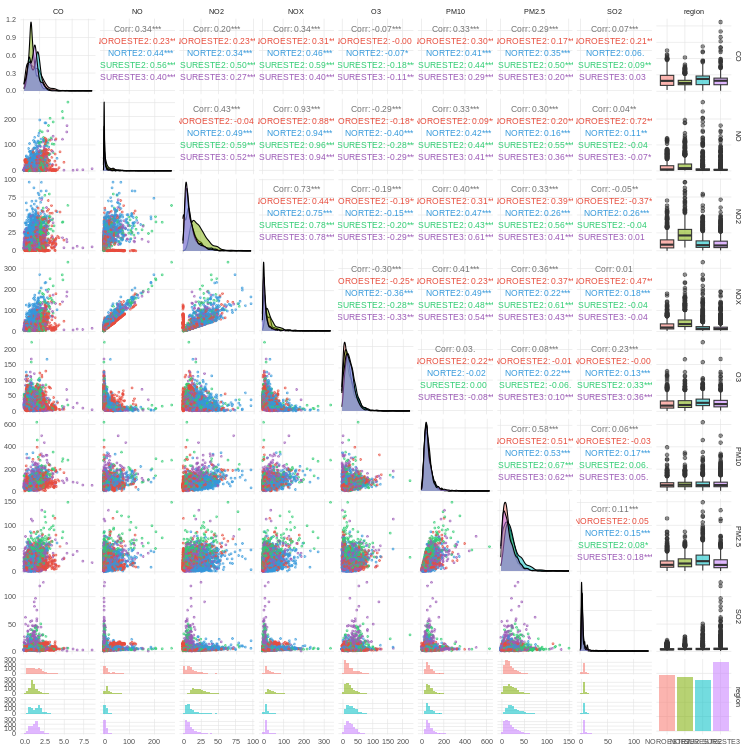

In [ ]:
%%R -i df_pair -w 750 -h 750 -u px

# Instalar las librerías necesarias
install.packages("GGally")
install.packages("ggplot2")

# Cargar las librerías
library(GGally)
library(ggplot2)

df_pair$region <- as.factor(df_pair$region)
pal <- c("#E74C3C", "#3498DB", "#2ECC71", "#9B59B6")

p <- ggpairs(
  df_pair,
  mapping = aes(color = region, alpha = 0.6),
  lower = list(continuous = wrap("points", size = 0.7)),
  diag  = list(continuous = wrap("densityDiag", alpha = 0.5),
               discrete   = "barDiag"),
  upper = list(continuous = wrap("cor", method = "pearson", digits = 2, size = 3))
) +
  theme_minimal(base_size = 9) +
  scale_color_manual(values = pal) +
  theme(panel.grid.major = element_line(color = "grey90", size = 0.3),
        panel.grid.minor = element_blank(),
        legend.position = "right")

print(p)

**Factor Analysis**

In [ ]:
# Unidades de los contaminantes

INPUT_UNITS = {
    "O3":   "ppb",   # dividir entre 1000
    "CO":   "ppm",   # ya correcto
    "SO2":  "ppb",   # dividir entre 1000
    "NO2":  "ppb",   # dividir entre 1000
    "PM10": "ugm3",  # µg/m3 directo
    "PM2.5":"ugm3"
}


In [ ]:
import pandas as pd

# Lee la hoja "PM10" del Excel
info = pd.read_excel("/content/datos2020.xlsx", sheet_name="PM10")
print(info.head())


  parameter                     date    SE SE_b     NE NE_b      CE CE_b  \
0     PM10   2020-01-01 00:00:00.000  66.0    x  110.0    x   86.34    x   
1     PM10   2020-01-01 01:00:00.000  57.0        75.0       112.01        
2     PM10   2020-01-01 02:00:00.000  68.0        76.0       100.01        
3     PM10   2020-01-01 03:00:00.000  68.0        46.0       106.20        
4     PM10   2020-01-01 04:00:00.000  48.0        63.0       141.86        

      NO NO_b  ...   SO2 SO2_b   SE3 SE3_b   SUR SUR_b  Norte2 NTE2_b  NE3  \
0   88.0    x  ...   NaN     x  37.0     l   NaN     l    69.0      l  NaN   
1   77.0       ...  42.0        37.0        20.0          49.0         NaN   
2  107.0       ...  43.0        55.0        24.0          53.0         NaN   
3   84.0       ...  47.0        35.0        39.0          51.0         NaN   
4   70.0       ...  50.0        27.0        23.0          50.0         NaN   

  NE3_b  
0     x  
1        
2        
3        
4        

[5 rows x 30 

In [ ]:
import math
import numpy as np
import pandas as pd

FILEPATH = "/content/datos2020.xlsx"
SHEET = "PM10"
YEAR = 2020
NOM_24H = 75.0

def find_datetime_col(df: pd.DataFrame) -> str:
    candidates = ["date", "fecha", "datetime", "time", "hora", "timestamp"]
    low = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c in low:
            return low[c]
    for c in df.columns:
        if np.issubdtype(df[c].dtype, np.datetime64):
            return c
    return df.columns[0]

def completeness_threshold(nmax: int) -> int:
    return 1 if nmax <= 1 else math.ceil(0.75 * nmax)

df = pd.read_excel(FILEPATH, sheet_name=SHEET)
time_col = find_datetime_col(df)
base_ignore = {time_col, "parameter"}
value_cols = [c for c in df.columns if (c not in base_ignore) and (not str(c).endswith("_b"))]

# A numérico
df[value_cols] = df[value_cols].apply(pd.to_numeric, errors="coerce")
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df = df.dropna(subset=[time_col])

# Año objetivo
df = df[df[time_col].dt.year == YEAR].copy()
if df.empty:
    raise ValueError(f"No hay datos en {YEAR} para {SHEET}.")

long_df = df.melt(id_vars=[time_col], value_vars=value_cols,
                  var_name="estacion", value_name="valor").dropna(subset=["valor"])
long_df = long_df.rename(columns={time_col: "timestamp"})
long_df["fecha"] = long_df["timestamp"].dt.date

# Criterio establecido por SIMA, del 75% de los datos
samples_per_day = (long_df.groupby(["estacion", "fecha"], as_index=False)
                   .agg(n=("valor", "size")))
max_per_station = (samples_per_day.groupby("estacion", as_index=False)["n"]
                   .max().rename(columns={"n": "n_max"}))
long_df = long_df.merge(max_per_station, on="estacion", how="left")

daily = (long_df.groupby(["estacion", "fecha"], as_index=False)
         .agg(media_diaria=("valor", "mean"),
              n=("valor", "size"),
              n_max=("n_max", "max")))
daily["min_validos"] = daily["n_max"].apply(completeness_threshold)
daily["dia_valido"] = daily["n"] >= daily["min_validos"]
daily["excede_nom"] = (daily["dia_valido"]) & (daily["media_diaria"] > NOM_24H)

# Convertimos fecha a datetime y luego a Periodo mensual
daily["fecha_dt"] = pd.to_datetime(daily["fecha"])
daily["periodo"] = daily["fecha_dt"].dt.to_period("M")
daily["dias_mes"] = daily["periodo"].dt.days_in_month

monthly = (daily.groupby(["estacion", "periodo"], as_index=False)
           .agg(dias_validos=("dia_valido", "sum"),
                dias_tot_mes=("dias_mes", "max"),
                prom_mensual=("media_diaria", "mean")))
monthly["min_dias_validos"] = (0.75 * monthly["dias_tot_mes"]).apply(math.ceil)
monthly["mes_valido"] = monthly["dias_validos"] >= monthly["min_dias_validos"]

daily_valid = daily[daily["dia_valido"]].copy()
max_global = daily_valid.loc[daily_valid["media_diaria"].idxmax()]

resumen_est = (daily_valid.groupby("estacion", as_index=False)
               .agg(dias_excedidos=("excede_nom", "sum"),
                    dias_validos=("dia_valido", "sum"),
                    prom_anual=("media_diaria", "mean")))
days_in_year = 366 if pd.Timestamp(f"{YEAR}-12-31").is_leap_year else 365
resumen_est["min_dias_validos_anual"] = math.ceil(0.75 * days_in_year)
resumen_est["anual_valido"] = resumen_est["dias_validos"] >= resumen_est["min_dias_validos_anual"]
resumen_est["pct_excedidos"] = 100 * resumen_est["dias_excedidos"] / resumen_est["dias_validos"]

# Día excedido si cualquier estación excede
zmm_excesos = (daily_valid
               .assign(any_exceso=lambda d: d["media_diaria"] > NOM_24H)
               .groupby("fecha", as_index=False)
               .agg(hay_exceso=("any_exceso", "max")))
dias_excedidos_zmm = int(zmm_excesos["hay_exceso"].sum())

print(f"\n==== {SHEET} {YEAR} ====")
print(f"NOM 24h: {NOM_24H} µg/m³")
print(f"Máximo diario global (válido): {max_global['media_diaria']:.2f} µg/m³ | "
      f"Estación: {max_global['estacion']} | Fecha: {max_global['fecha']}")
print(f"Días excedidos en la ZMM (>=1 estación): {dias_excedidos_zmm}")

print("\n--- Top 10 días más altos (válidos) ---")
display(daily_valid.sort_values("media_diaria", ascending=False)
        .head(10)[["estacion","fecha","media_diaria","n","min_validos","excede_nom"]])

print("\n--- Resumen por estación ---")
display(resumen_est.sort_values("dias_excedidos", ascending=False)
        [["estacion","dias_excedidos","dias_validos","pct_excedidos","anual_valido","prom_anual"]])

print("\n--- Mensual (solo meses válidos) ---")
display(monthly[monthly["mes_valido"]]
        .sort_values(["estacion","periodo"])
        [["estacion","periodo","prom_mensual","dias_validos","min_dias_validos"]]
        .head(30))



==== PM10 2020 ====
NOM 24h: 75.0 µg/m³
Máximo diario global (válido): 179.45 µg/m³ | Estación: SE | Fecha: 2020-12-24
Días excedidos en la ZMM (>=1 estación): 153

--- Top 10 días más altos (válidos) ---


,estacion,fecha,media_diaria,n,min_validos,excede_nom
2899,SE,2020-12-24,179.452917,24,18,True
3602,SE3,2020-12-24,173.916667,24,18,True
3958,SO,2020-12-15,173.791667,24,18,True
3957,SO,2020-12-14,173.625000,24,18,True
3619,SO,2020-01-10,171.583333,24,18,True
1195,NO,2020-01-15,170.833333,24,18,True
3967,SO,2020-12-24,168.215833,24,18,True
4313,SO2,2020-12-24,166.583333,24,18,True
347,CE,2020-12-14,164.250000,24,18,True
4303,SO2,2020-12-14,163.250000,24,18,True



--- Resumen por estación ---


,estacion,dias_excedidos,dias_validos,pct_excedidos,anual_valido,prom_anual
11,SO,105,357,29.411765,True,62.894350
10,SE3,83,341,24.340176,True,62.980533
7,Norte2,72,329,21.884498,True,59.431860
1,NE,71,338,21.005917,True,55.923237
12,SO2,62,326,19.018405,True,56.879425
5,NO2,59,354,16.666667,True,53.805787
4,NO,49,349,14.040115,True,48.159792
0,CE,48,344,13.953488,True,51.751692
9,SE2,39,327,11.926606,True,50.215869
8,SE,38,340,11.176471,True,48.083670



--- Mensual (solo meses válidos) ---


,estacion,periodo,prom_mensual,dias_validos,min_dias_validos
0,CE,2020-01,69.282469,31,24
1,CE,2020-02,54.313448,29,22
2,CE,2020-03,48.850913,31,24
3,CE,2020-04,36.752174,30,23
4,CE,2020-05,29.009269,31,24
5,CE,2020-06,27.480911,26,23
6,CE,2020-07,45.901171,29,24
7,CE,2020-08,31.144458,24,24
9,CE,2020-10,62.235445,30,24
10,CE,2020-11,61.758086,30,23


In [ ]:
info.tail()

,parameter,date,SE,SE_b,NE,NE_b,CE,CE_b,NO,NO_b,...,SO2,SO2_b,SE3,SE3_b,SUR,SUR_b,Norte2,NTE2_b,NE3,NE3_b
8770,PM10,2020-12-31 19:00:00.000,NaN,x,57.57,,46.0,,43.63,,...,100.0,,75.0,,47.0,,67.0,,52.0,
8771,PM10,2020-12-31 20:00:00.000,NaN,x,52.29,,43.0,,45.62,,...,66.0,,67.0,,35.0,,71.0,,29.0,
8772,PM10,2020-12-31 21:00:00.000,137.21,,89.82,,41.0,,57.99,,...,57.0,,49.0,,34.0,,61.0,,16.0,
8773,PM10,2020-12-31 22:00:00.000,167.26,,146.33,,46.0,,114.37,,...,44.0,,42.0,,34.0,,66.0,,24.0,
8774,PM10,2020-12-31 23:00:00.000,96.57,,118.78,,63.0,,NaN,x,...,49.0,,48.0,,34.0,,97.0,,8.0,


## Análisis 2020

In [ ]:
import pandas as pd

PATH = "/content/datos.xlsx"
xls = pd.ExcelFile(PATH)
print("Hojas:", xls.sheet_names)


Hojas: ['SURESTE', 'NORESTE', 'CENTRO', 'NOROESTE', 'SUROESTE', 'NOROESTE2', 'NORTE', 'SUROESTE2', 'SURESTE2', 'SURESTE3', 'SUR', 'NORTE2', 'NORESTE2', 'NORESTE3', 'NOROESTE3', 'CATÁLOGO']


In [ ]:
est_sureste = pd.read_excel(PATH, sheet_name="SURESTE")
print(est_sureste.head())


                 date    CO  NO  NO2  NOX    O3  PM10  PM2.5    PRS  RAINF  \
0 2020-01-01 00:00:00   NaN NaN  NaN  NaN   NaN  66.0  54.23    NaN    NaN   
1 2020-01-01 01:00:00  2.11 NaN  NaN  NaN  19.0  57.0    NaN  735.7    0.0   
2 2020-01-01 02:00:00  2.06 NaN  NaN  NaN  19.0  68.0  53.84  734.8    0.0   
3 2020-01-01 03:00:00  1.96 NaN  NaN  NaN  19.0  68.0  36.47  734.2    0.0   
4 2020-01-01 04:00:00  1.98 NaN  NaN  NaN  16.0  48.0  33.59  733.9    0.0   

     RH  SO2    SR   TOUT  WSR  WDR  
0   NaN  NaN  0.00    NaN  NaN  NaN  
1  96.0  5.4  0.01  11.20  8.1  NaN  
2  96.0  5.5  0.01  11.26  5.5  NaN  
3  96.0  5.4  0.01  11.35  3.8  NaN  
4  96.0  5.5  0.01  11.47  3.3  NaN  


In [ ]:
all_sheets = pd.read_excel(PATH, sheet_name=None)  # dict: nombre_hoja -> DataFrame
print(list(all_sheets.keys()))  # nombres de hojas


['SURESTE', 'NORESTE', 'CENTRO', 'NOROESTE', 'SUROESTE', 'NOROESTE2', 'NORTE', 'SUROESTE2', 'SURESTE2', 'SURESTE3', 'SUR', 'NORTE2', 'NORESTE2', 'NORESTE3', 'NOROESTE3', 'CATÁLOGO']


[Aviso] Hojas sin pm10 (omitidas): ['NOROESTE3']
PM10 2020 – Días sobre/debajo de la NOM-025 (ZMM)
  Días sobre la Norma:  153
  Días debajo de la Norma: 213
  Total días evaluados (≥1 estación válida): 366


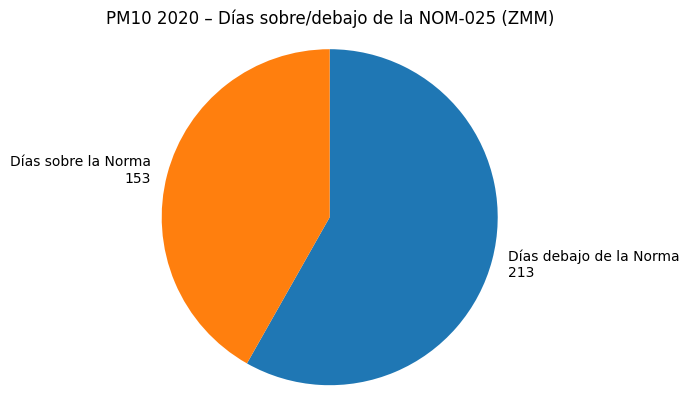

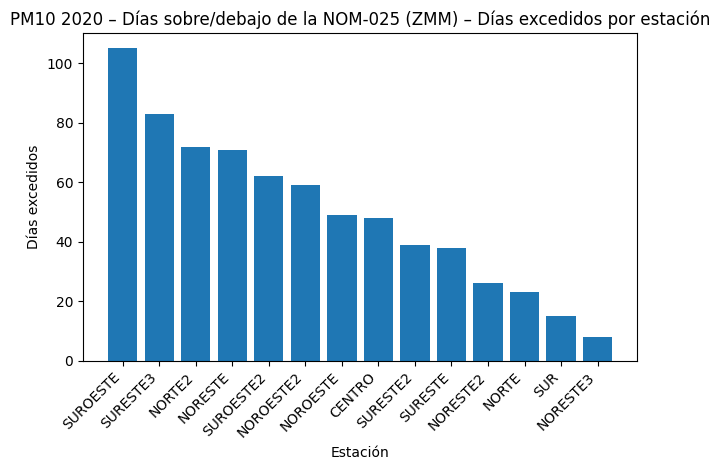

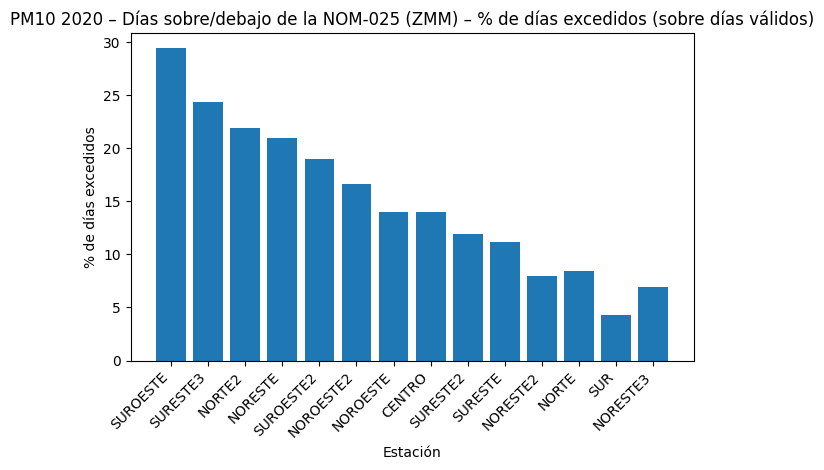

[Aviso] Hojas sin pm25 (omitidas): ['NOROESTE3']
PM2.5 2020 – Días sobre/debajo de la NOM-025 (ZMM)
  Días sobre la Norma:  37
  Días debajo de la Norma: 329
  Total días evaluados (≥1 estación válida): 366


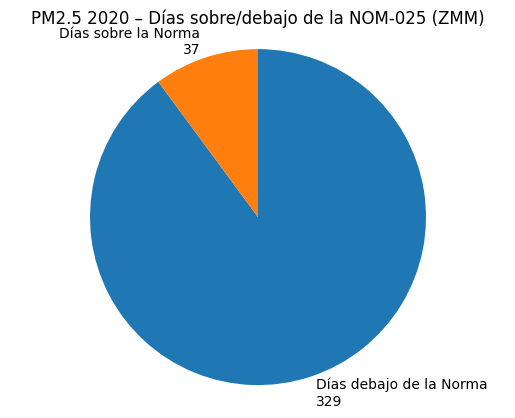

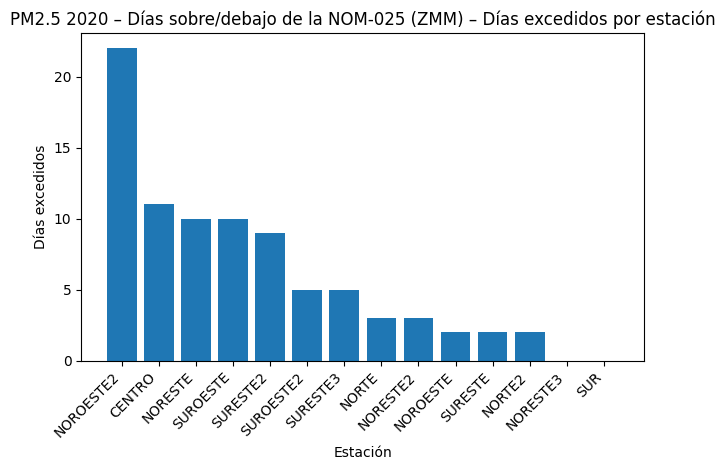

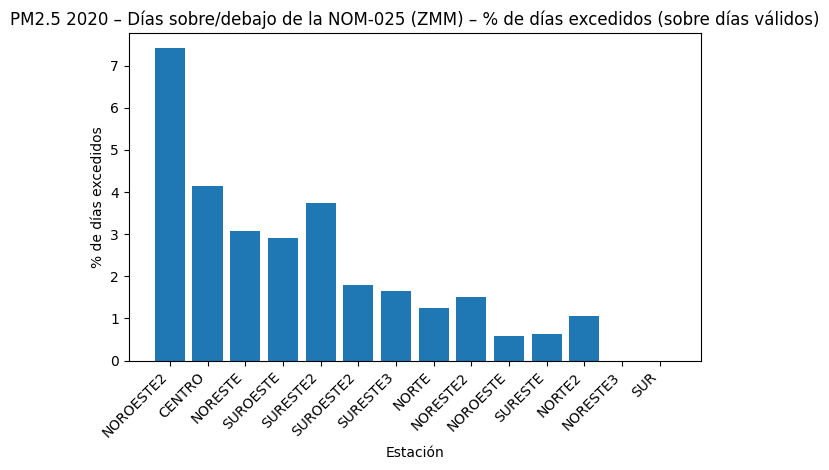

[Aviso] Hojas sin o3 (omitidas): ['NOROESTE3']
O₃ 2020 – Días con ≥1 h sobre la NOM-020 (ZMM)
  Días sobre la Norma:  62
  Días debajo de la Norma: 304
  Total días evaluados (≥1 estación válida): 366


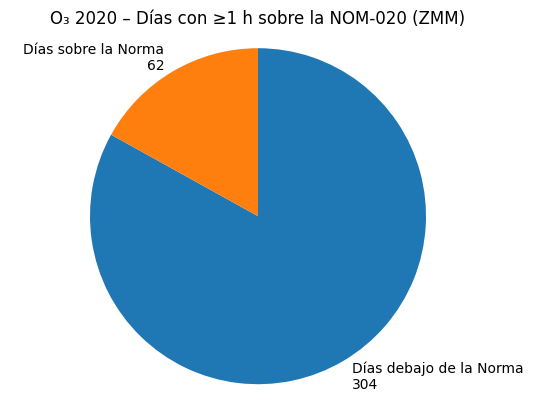

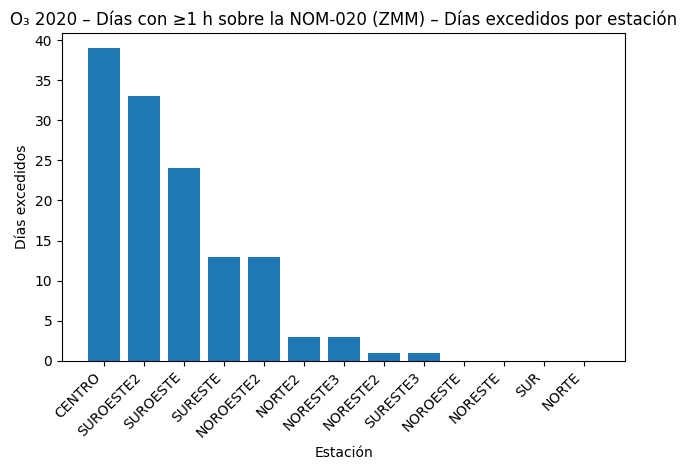

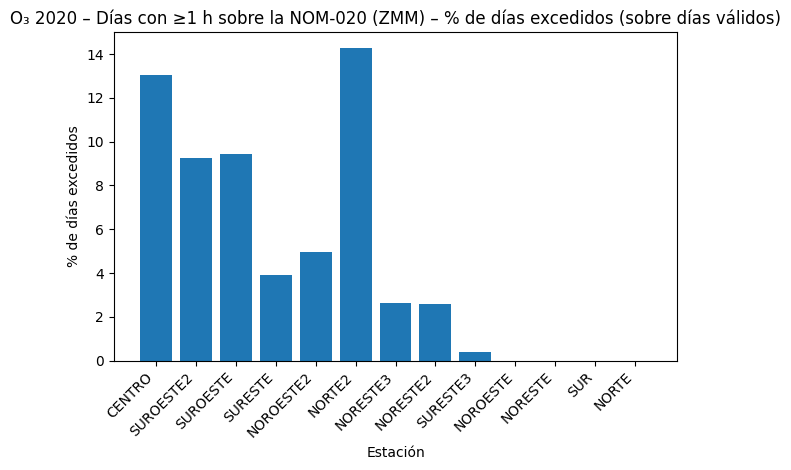

[Aviso] Hojas sin so2 (omitidas): ['NOROESTE3']
SO₂ 2020 – Días con ≥1 h sobre la NOM-022 (ZMM)
  Días sobre la Norma:  20
  Días debajo de la Norma: 346
  Total días evaluados (≥1 estación válida): 366


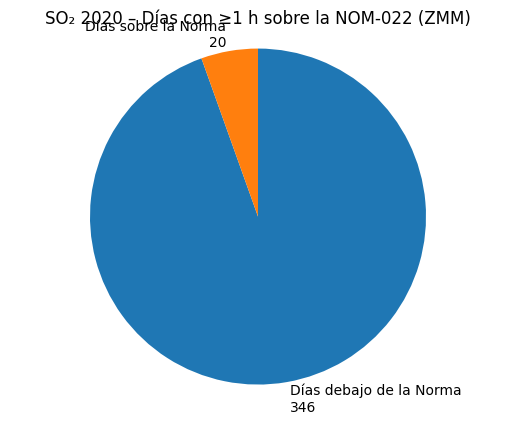

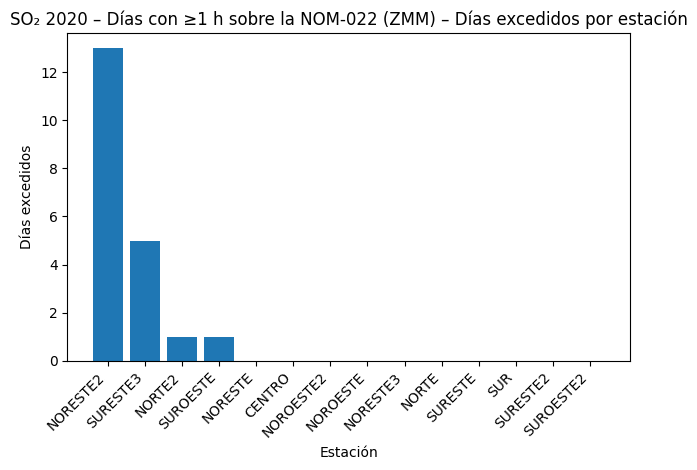

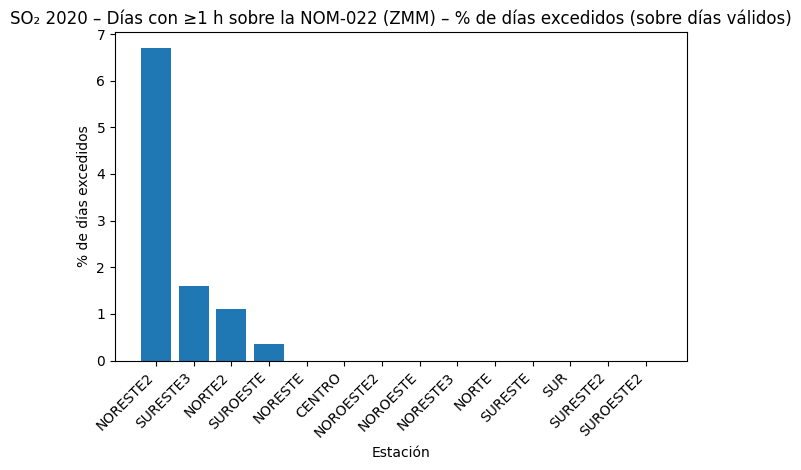

[Aviso] Hojas sin no2 (omitidas): ['NOROESTE3']
NO₂ 2020 – Días con ≥1 h sobre la NOM-023 (ZMM)
  Días sobre la Norma:  0
  Días debajo de la Norma: 366
  Total días evaluados (≥1 estación válida): 366


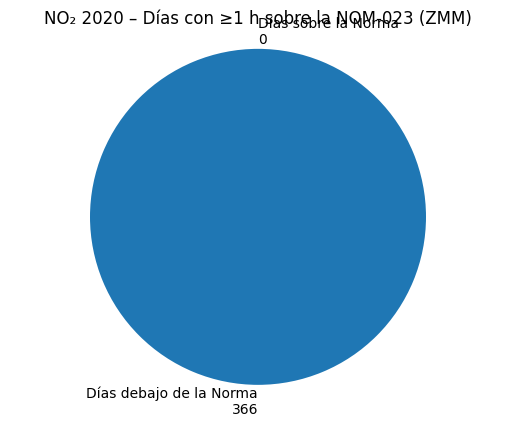

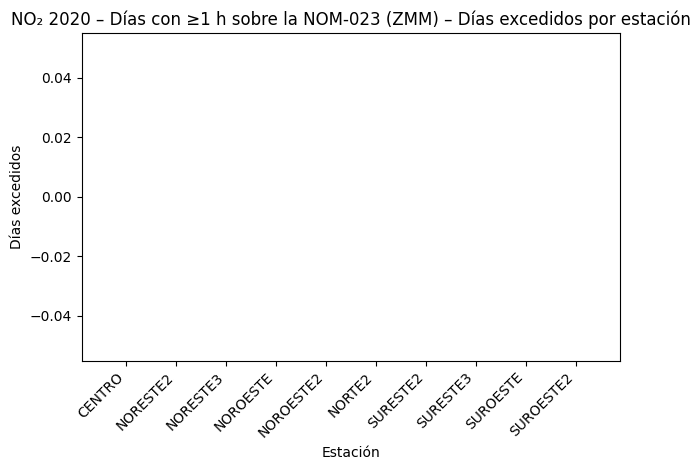

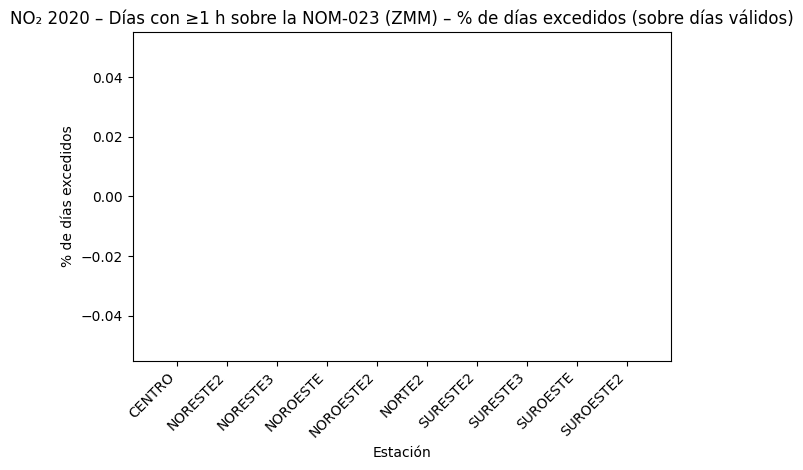

[Aviso] Hojas sin co (omitidas): ['NOROESTE3']
CO 2020 – Días con ≥1 h sobre la NOM-021 (ZMM)
  Días sobre la Norma:  0
  Días debajo de la Norma: 366
  Total días evaluados (≥1 estación válida): 366


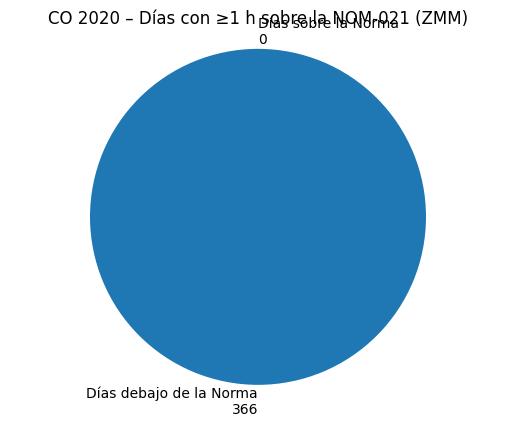

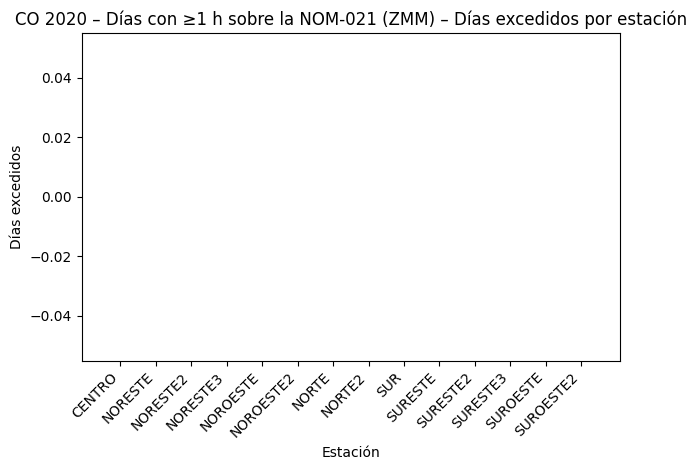

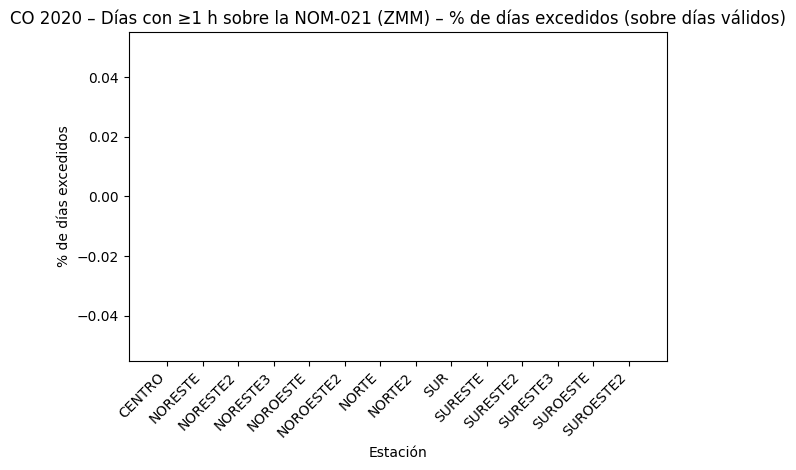

In [ ]:
import re, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PATH_STATIONS = "/content/datos.xlsx"
YEAR = 2020

# Límites permisibles
LIMITS = {
    "PM10": {"mode": "mean24h", "limit": 75.0,  "title": "PM10 {year} – Días sobre/debajo de la NOM-025 (ZMM)"},
    "PM2.5":{"mode": "mean24h", "limit": 45.0,  "title": "PM2.5 {year} – Días sobre/debajo de la NOM-025 (ZMM)"},
    "O3":   {"mode": "max1h",   "limit": 95.0,  "title": "O₃ {year} – Días con ≥1 h sobre la NOM-020 (ZMM)"},
    "SO2":  {"mode": "max1h",   "limit": 75.0,  "title": "SO₂ {year} – Días con ≥1 h sobre la NOM-022 (ZMM)"},
    "NO2":  {"mode": "max1h",   "limit": 210.0, "title": "NO₂ {year} – Días con ≥1 h sobre la NOM-023 (ZMM)"},
    "CO":   {"mode": "max1h",   "limit": 35.0,  "title": "CO {year} – Días con ≥1 h sobre la NOM-021 (ZMM)"},
}

def _norm(s: str) -> str:
    s = str(s).lower()
    s = s.replace("á","a").replace("é","e").replace("í","i").replace("ó","o").replace("ú","u")
    s = s.replace("pm2.5","pm25").replace("pm2_5","pm25")
    s = re.sub(r"[^a-z0-9]", "", s)
    return s

def find_datetime_col(df: pd.DataFrame) -> str:
    for c in ["date","fecha","datetime","time","hora","timestamp"]:
        m = {x.lower(): x for x in df.columns}
        if c in m: return m[c]
    for c in df.columns:
        if np.issubdtype(df[c].dtype, np.datetime64):
            return c
    return df.columns[0]

def find_pollutant_col(df: pd.DataFrame, pollutant_key: str) -> str | None:
    """
    pollutant_key normalizado: 'pm10','pm25','o3','so2','no2','co'
    Ignora flags tipo *_b. Intenta match exacto y luego flexible (e.g., 'o3ppb').
    """
    pk = _norm(pollutant_key)
    for c in df.columns:
        cn = _norm(c)
        if cn.endswith("b"):
            continue
        if cn == pk:
            return c
    for c in df.columns:
        cn = _norm(c)
        if cn.endswith("b"):
            continue
        if pk in cn:
            return c
    return None

def completeness_threshold(nmax: int) -> int:
    return 1 if nmax <= 1 else math.ceil(0.75 * nmax)

def load_long_from_station_book(path, year, pollutant_key):
    """
    Lee TODAS las hojas (estaciones) y extrae la serie del contaminante elegido.
    Devuelve long_df: [timestamp, fecha, estacion, valor]
    """
    xls = pd.ExcelFile(path)
    sheets = [s for s in xls.sheet_names if _norm(s) not in {"catalogo","catalogohoja","catalogo1"}]
    frames, skipped = [], []

    for sh in sheets:
        df = pd.read_excel(path, sheet_name=sh)
        tcol = find_datetime_col(df)
        pcol = find_pollutant_col(df, pollutant_key)
        if pcol is None:
            skipped.append(sh)
            continue

        df[tcol] = pd.to_datetime(df[tcol], errors="coerce")
        df = df.dropna(subset=[tcol])
        df = df[df[tcol].dt.year == year].copy()
        if df.empty:
            continue
        vals = pd.to_numeric(df[pcol], errors="coerce")
        tmp = pd.DataFrame({"timestamp": df[tcol].values, "estacion": sh, "valor": vals.values})
        tmp = tmp.dropna(subset=["valor"])
        tmp["fecha"] = tmp["timestamp"].dt.date
        frames.append(tmp)

    if not frames:
        raise ValueError(f"No se encontró el contaminante {pollutant_key} en ninguna hoja de estación.")
    long_df = pd.concat(frames, ignore_index=True)
    if skipped:
        print(f"[Aviso] Hojas sin {pollutant_key} (omitidas):", sorted(skipped))
    return long_df

def summarize_and_plots(long_df, mode, limit, title):
    spd = long_df.groupby(["estacion","fecha"], as_index=False).agg(n=("valor","size"))
    nmax = spd.groupby("estacion", as_index=False)["n"].max().rename(columns={"n":"n_max"})
    df2 = long_df.merge(nmax, on="estacion", how="left")
    if mode == "mean24h":
        daily = (df2.groupby(["estacion","fecha"], as_index=False)
                 .agg(agregado=("valor","mean"), n=("valor","size"), n_max=("n_max","max")))
    elif mode == "max1h":
        daily = (df2.groupby(["estacion","fecha"], as_index=False)
                 .agg(agregado=("valor","max"),  n=("valor","size"), n_max=("n_max","max")))
    else:
        raise ValueError("mode debe ser 'mean24h' o 'max1h'.")

    daily["min_validos"] = daily["n_max"].apply(completeness_threshold)
    daily["dia_valido"]  = daily["n"] >= daily["min_validos"]
    daily["excede_nom"]  = (daily["dia_valido"]) & (daily["agregado"] > limit)
    daily_valid = daily[daily["dia_valido"]].copy()

    zmm = (daily_valid.assign(any_exceso=lambda d: d["agregado"] > limit)
           .groupby("fecha", as_index=False).agg(hay_exceso=("any_exceso","max")))
    dias_excedidos    = int(zmm["hay_exceso"].sum())
    dias_no_excedidos = int((~zmm["hay_exceso"]).sum())
    print(title.format(year=YEAR))
    print("  Días sobre la Norma: ", dias_excedidos)
    print("  Días debajo de la Norma:", dias_no_excedidos)
    print("  Total días evaluados (≥1 estación válida):", len(zmm))
    labels = [f"Días debajo de la Norma\n{dias_no_excedidos}",
              f"Días sobre la Norma\n{dias_excedidos}"]
    sizes  = [dias_no_excedidos, dias_excedidos]
    plt.figure()
    plt.pie(sizes, labels=labels, startangle=90, counterclock=False)
    plt.title(title.format(year=YEAR))
    plt.axis("equal")
    plt.show()
    resumen = (daily_valid.groupby("estacion", as_index=False)
               .agg(dias_excedidos=("excede_nom","sum"),
                    dias_validos=("dia_valido","sum")))
    resumen["pct_excedidos"] = 100 * resumen["dias_excedidos"] / resumen["dias_validos"]
    resumen = resumen.sort_values("dias_excedidos", ascending=False)

    plt.figure()
    plt.bar(resumen["estacion"], resumen["dias_excedidos"])
    plt.title(title.format(year=YEAR) + " – Días excedidos por estación")
    plt.ylabel("Días excedidos")
    plt.xlabel("Estación")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.bar(resumen["estacion"], resumen["pct_excedidos"])
    plt.title(title.format(year=YEAR) + " – % de días excedidos (sobre días válidos)")
    plt.ylabel("% de días excedidos")
    plt.xlabel("Estación")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    return daily_valid, resumen

for sheet_label, cfg in LIMITS.items():
    key = sheet_label.lower().replace("2.5","25")
    long_df = load_long_from_station_book(PATH_STATIONS, YEAR, pollutant_key=key)
    summarize_and_plots(long_df, mode=cfg["mode"], limit=cfg["limit"], title=cfg["title"])


## Análisis 2021

In [ ]:
info2020 = all_sheets


PM10 2021 – Días sobre/debajo de la NOM-025 (ZMM)
  Días sobre la Norma:  190
  Días debajo de la Norma: 175
  Total días evaluados (≥1 estación válida): 365


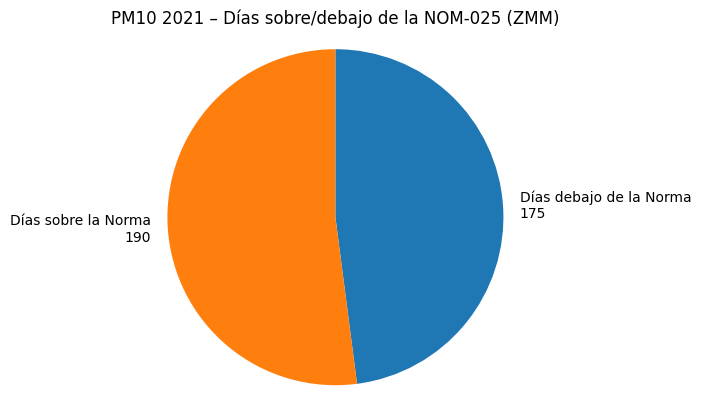

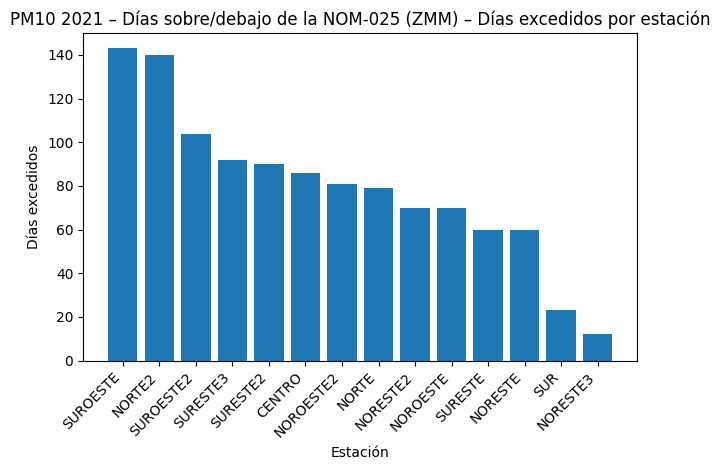

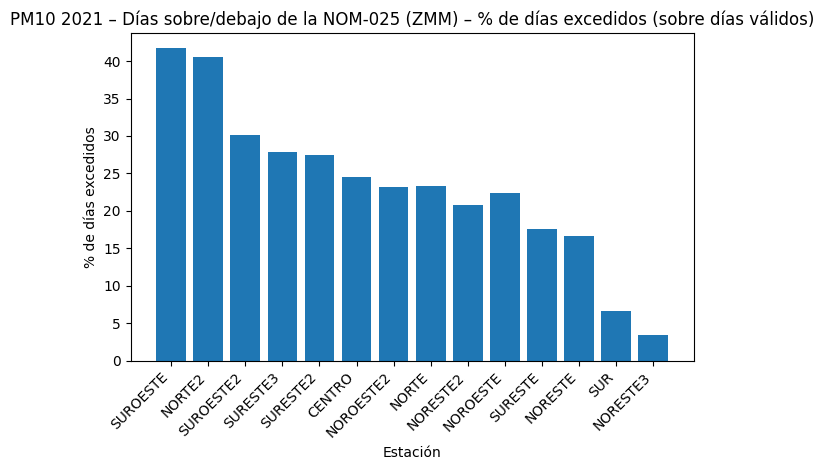

PM2.5 2021 – Días sobre/debajo de la NOM-025 (ZMM)
  Días sobre la Norma:  63
  Días debajo de la Norma: 302
  Total días evaluados (≥1 estación válida): 365


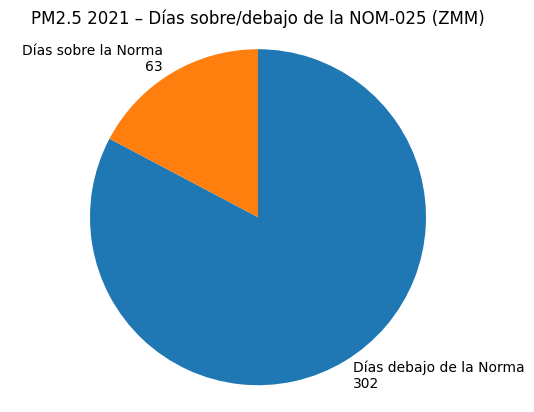

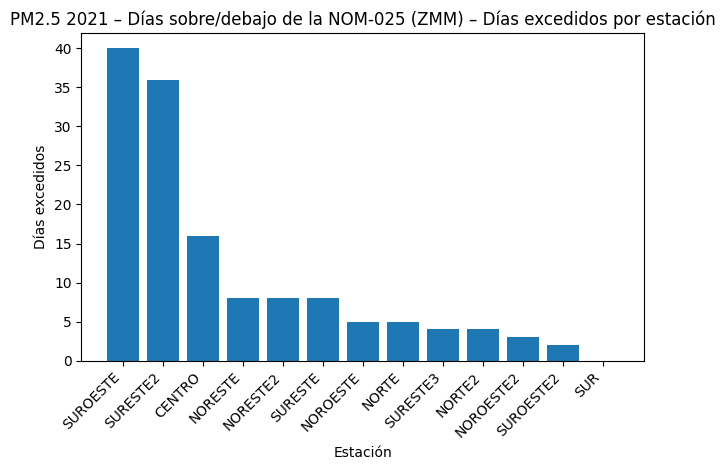

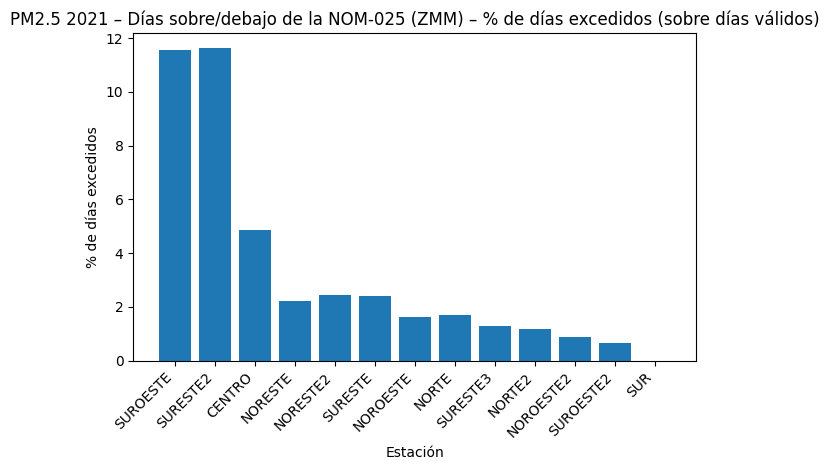

O₃ 2021 – Días con ≥1 h sobre la NOM-020 (ZMM)
  Días sobre la Norma:  83
  Días debajo de la Norma: 282
  Total días evaluados (≥1 estación válida): 365


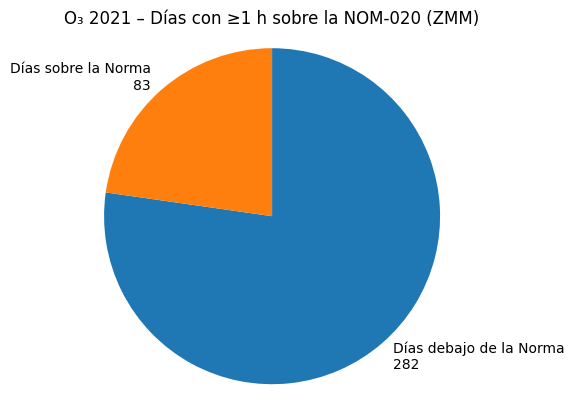

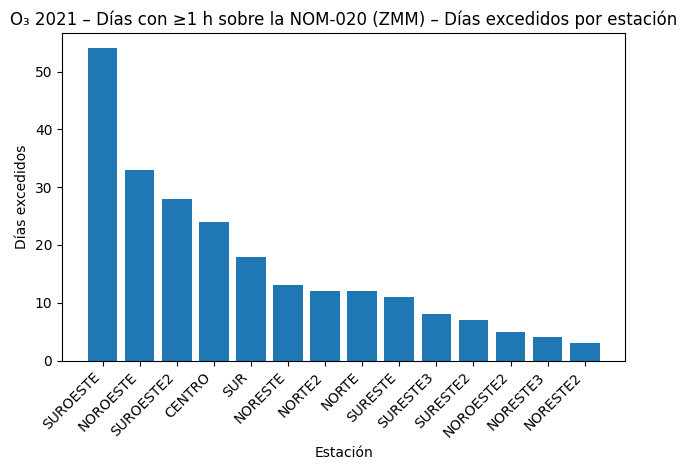

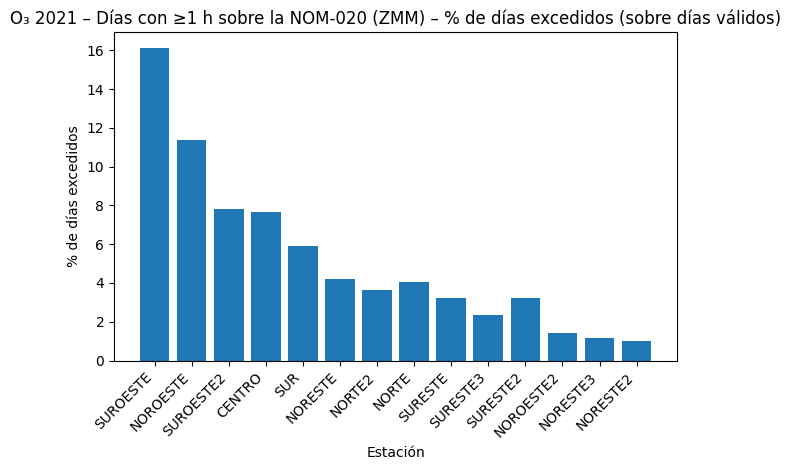

SO₂ 2021 – Días con ≥1 h sobre la NOM-022 (ZMM)
  Días sobre la Norma:  32
  Días debajo de la Norma: 333
  Total días evaluados (≥1 estación válida): 365


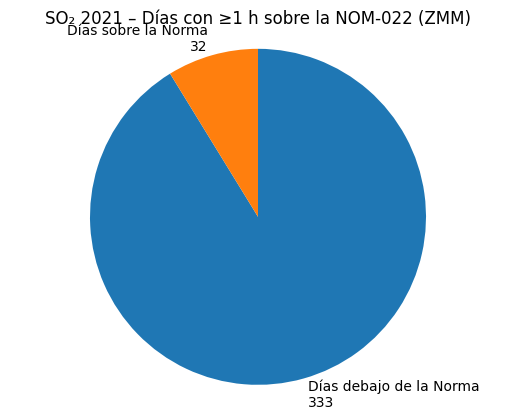

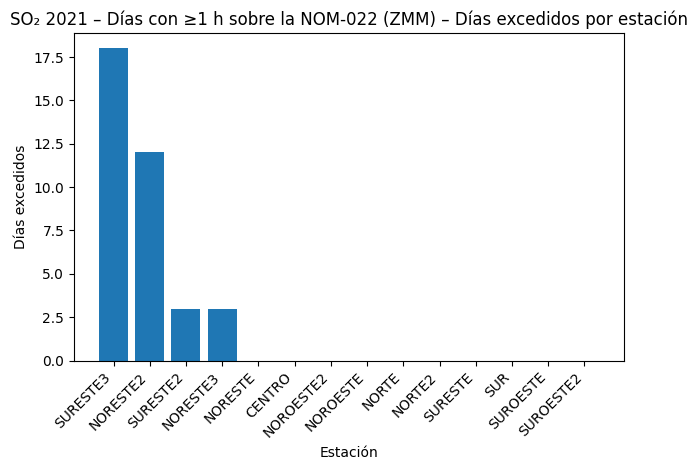

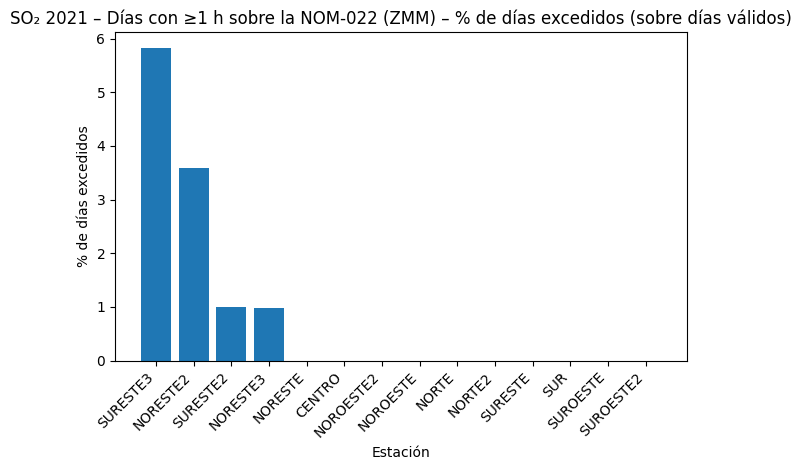

NO₂ 2021 – Días con ≥1 h sobre la NOM-023 (ZMM)
  Días sobre la Norma:  0
  Días debajo de la Norma: 365
  Total días evaluados (≥1 estación válida): 365


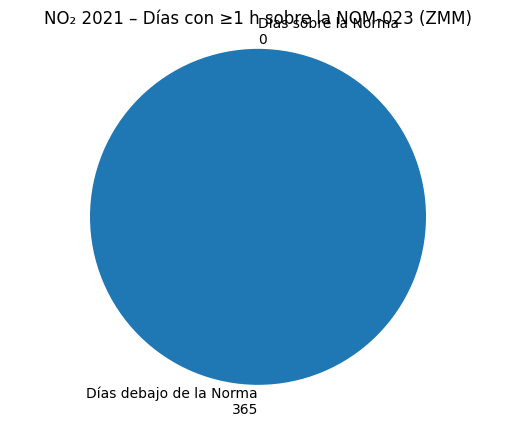

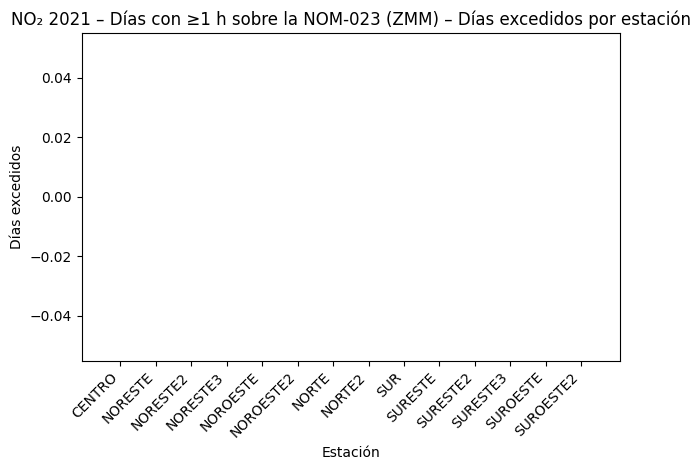

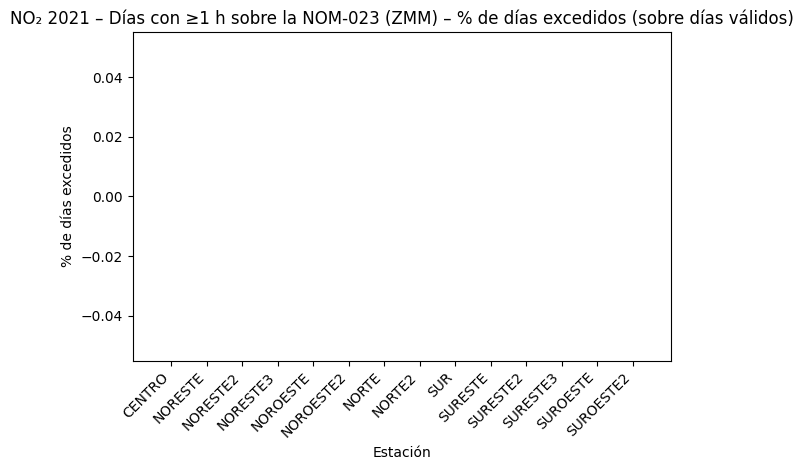

CO 2021 – Días con ≥1 h sobre la NOM-021 (ZMM)
  Días sobre la Norma:  0
  Días debajo de la Norma: 365
  Total días evaluados (≥1 estación válida): 365


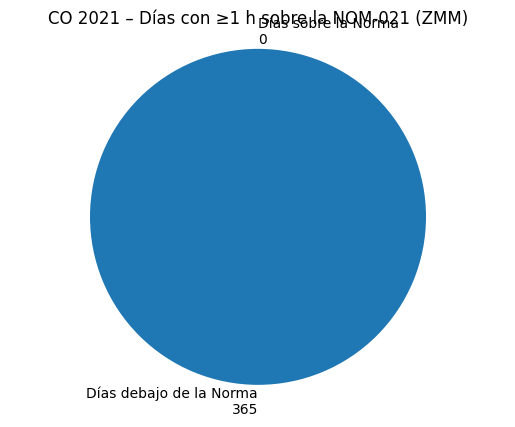

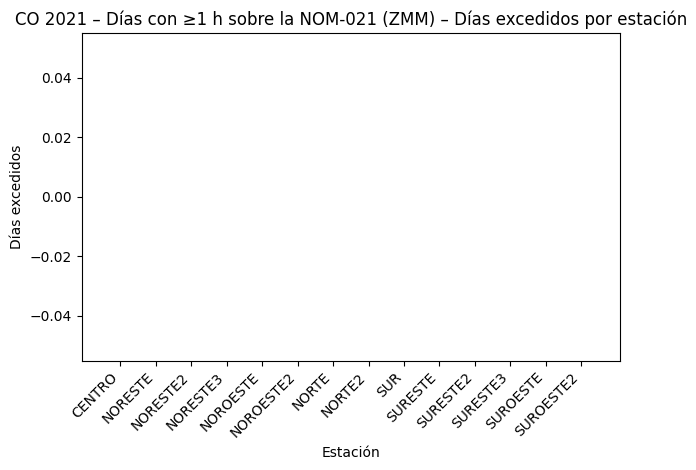

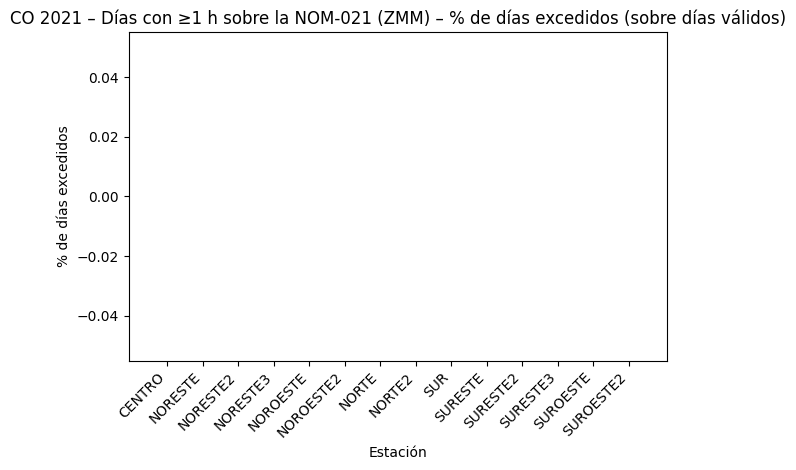

In [ ]:
import re, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

YEAR = 2021
LIMITS = {
    "PM10": {"mode": "mean24h", "limit": 75.0,  "title": "PM10 {year} – Días sobre/debajo de la NOM-025 (ZMM)"},
    "PM2.5":{"mode": "mean24h", "limit": 45.0,  "title": "PM2.5 {year} – Días sobre/debajo de la NOM-025 (ZMM)"},
    "O3":   {"mode": "max1h",   "limit": 95.0,  "title": "O₃ {year} – Días con ≥1 h sobre la NOM-020 (ZMM)"},
    "SO2":  {"mode": "max1h",   "limit": 75.0,  "title": "SO₂ {year} – Días con ≥1 h sobre la NOM-022 (ZMM)"},
    "NO2":  {"mode": "max1h",   "limit": 210.0, "title": "NO₂ {year} – Días con ≥1 h sobre la NOM-023 (ZMM)"},
    "CO":   {"mode": "max1h",   "limit": 35.0,  "title": "CO {year} – Días con ≥1 h sobre la NOM-021 (ZMM)"},
}

def _norm(s: str) -> str:
    s = str(s).lower()
    s = s.replace("á","a").replace("é","e").replace("í","i").replace("ó","o").replace("ú","u")
    s = s.replace("pm2.5","pm25").replace("pm2_5","pm25")
    s = re.sub(r"[^a-z0-9]", "", s)
    return s

def find_datetime_col(df: pd.DataFrame) -> str:
    m = {c.lower(): c for c in df.columns}
    for k in ["date","fecha","datetime","time","hora","timestamp"]:
        if k in m: return m[k]
    for c in df.columns:
        if np.issubdtype(df[c].dtype, np.datetime64): return c
    return df.columns[0]

def find_pollutant_col(df: pd.DataFrame, pollutant_key: str) -> str|None:
    pk = _norm(pollutant_key)
    for c in df.columns:
        cn = _norm(c)
        if cn.endswith("b"): continue
        if cn == pk: return c
    for c in df.columns:
        cn = _norm(c)
        if cn.endswith("b"): continue
        if pk in cn: return c
    return None

def completeness_threshold(nmax: int) -> int:
    return 1 if nmax <= 1 else math.ceil(0.75 * nmax)

def build_long_from_info(info_dict, year, pollutant_key):
    if not isinstance(info_dict, dict):
        raise TypeError("Se esperaba que 'info2020' fuera un dict de hojas (sheet_name=None).")
    frames, skipped = [], []
    for station_name, df in info_dict.items():
        if _norm(station_name) in {"catalogo","catalogohoja","catalogo1"}:
            continue
        if not isinstance(df, pd.DataFrame) or df.empty:
            continue
        tcol = find_datetime_col(df)
        pcol = find_pollutant_col(df, pollutant_key)
        if pcol is None:
            skipped.append(station_name); continue
        tmp = df[[tcol, pcol]].copy()
        tmp[tcol] = pd.to_datetime(tmp[tcol], errors="coerce")
        tmp = tmp.dropna(subset=[tcol])
        tmp = tmp[tmp[tcol].dt.year == year]
        if tmp.empty: continue
        tmp[pcol] = pd.to_numeric(tmp[pcol], errors="coerce")
        tmp = tmp.dropna(subset=[pcol])
        if tmp.empty: continue
        out = pd.DataFrame({
            "timestamp": tmp[tcol].values,
            "estacion": station_name,
            "valor": tmp[pcol].values
        })
        out["fecha"] = pd.to_datetime(out["timestamp"]).dt.date
        frames.append(out)
    if not frames:
        raise ValueError(f"No se encontró '{pollutant_key}' en estaciones para {year}. Omitidas: {sorted(skipped)}")
    long_df = pd.concat(frames, ignore_index=True)
    if skipped:
        print(f"[Aviso] Hojas sin {pollutant_key} (omitidas):", sorted(skipped))
    return long_df

def summarize_and_plots(long_df, mode, limit, title):
    spd = long_df.groupby(["estacion","fecha"], as_index=False).agg(n=("valor","size"))
    nmax = spd.groupby("estacion", as_index=False)["n"].max().rename(columns={"n":"n_max"})
    df2 = long_df.merge(nmax, on="estacion", how="left")
    if mode == "mean24h":
        daily = (df2.groupby(["estacion","fecha"], as_index=False)
                 .agg(agregado=("valor","mean"), n=("valor","size"), n_max=("n_max","max")))
    elif mode == "max1h":
        daily = (df2.groupby(["estacion","fecha"], as_index=False)
                 .agg(agregado=("valor","max"),  n=("valor","size"), n_max=("n_max","max")))
    else:
        raise ValueError("mode debe ser 'mean24h' o 'max1h'.")

    daily["min_validos"] = daily["n_max"].apply(completeness_threshold)
    daily["dia_valido"]  = daily["n"] >= daily["min_validos"]
    daily["excede_nom"]  = (daily["dia_valido"]) & (daily["agregado"] > limit)
    daily_valid = daily[daily["dia_valido"]].copy()
    zmm = (daily_valid.assign(any_exceso=lambda d: d["agregado"] > limit)
           .groupby("fecha", as_index=False).agg(hay_exceso=("any_exceso","max")))
    dias_excedidos    = int(zmm["hay_exceso"].sum())
    dias_no_excedidos = int((~zmm["hay_exceso"]).sum())

    print(title.format(year=YEAR))
    print("  Días sobre la Norma: ", dias_excedidos)
    print("  Días debajo de la Norma:", dias_no_excedidos)
    print("  Total días evaluados (≥1 estación válida):", len(zmm))

    plt.figure()
    labels = [f"Días debajo de la Norma\n{dias_no_excedidos}",
              f"Días sobre la Norma\n{dias_excedidos}"]
    sizes  = [dias_no_excedidos, dias_excedidos]
    plt.pie(sizes, labels=labels, startangle=90, counterclock=False)
    plt.title(title.format(year=YEAR))
    plt.axis("equal")
    plt.show()

    resumen = (daily_valid.groupby("estacion", as_index=False)
               .agg(dias_excedidos=("excede_nom","sum"),
                    dias_validos=("dia_valido","sum")))
    resumen["pct_excedidos"] = 100 * resumen["dias_excedidos"] / resumen["dias_validos"]
    resumen = resumen.sort_values("dias_excedidos", ascending=False)

    plt.figure()
    plt.bar(resumen["estacion"], resumen["dias_excedidos"])
    plt.title(title.format(year=YEAR) + " – Días excedidos por estación")
    plt.ylabel("Días excedidos")
    plt.xlabel("Estación")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.bar(resumen["estacion"], resumen["pct_excedidos"])
    plt.title(title.format(year=YEAR) + " – % de días excedidos (sobre días válidos)")
    plt.ylabel("% de días excedidos")
    plt.xlabel("Estación")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    return daily_valid, resumen

for label, cfg in LIMITS.items():
    key = label.lower().replace("2.5","25")
    long_df = build_long_from_info(info2020, YEAR, pollutant_key=key)
    summarize_and_plots(long_df, mode=cfg["mode"], limit=cfg["limit"], title=cfg["title"])


## Análisis 2022

In [ ]:
import pandas as pd

PATH = "/content/datos2022.xlsx"
xls2022 = pd.ExcelFile(PATH)
print("Hojas:", xls.sheet_names)


Hojas: ['SURESTE', 'NORESTE', 'CENTRO', 'NOROESTE', 'SUROESTE', 'NOROESTE2', 'NORTE', 'SUROESTE2', 'SURESTE2', 'SURESTE3', 'SUR', 'NORTE2', 'NORESTE2', 'NORESTE3', 'NOROESTE3', 'CATÁLOGO']


In [ ]:
est_sureste = pd.read_excel(PATH, sheet_name="SURESTE")
print(est_sureste.head())


                 date    CO    NO   NO2   NOX   O3   PM10   PM2.5    PRS  \
0 2022-01-01 00:00:00  2.36  19.8  48.4  68.0  5.0  142.0  111.00  715.7   
1 2022-01-01 01:00:00  2.29  10.8  44.5  55.1  6.0  168.0  112.16  715.5   
2 2022-01-01 02:00:00  2.71  28.3  47.1  75.2  4.0  203.0  139.31  715.4   
3 2022-01-01 03:00:00  2.31  19.6  42.1  61.5  5.0  262.0  177.68  715.1   
4 2022-01-01 04:00:00  1.85  13.0  39.5  52.5  4.0  185.0  134.21  715.1   

   RAINF    RH  SO2   SR   TOUT  WSR    WDR  
0    0.0  59.0  4.0  0.0  21.65  6.5  285.0  
1    0.0  59.0  4.6  0.0  21.21  7.1  284.0  
2    0.0  62.0  5.9  0.0  21.21  7.7  290.0  
3    0.0  59.0  5.5  0.0  20.44  8.2  294.0  
4    0.0  59.0  4.9  0.0  19.80  8.1  287.0  


In [ ]:
all_sheets2022 = pd.read_excel(PATH, sheet_name=None)
print(list(all_sheets.keys()))


['SURESTE', 'NORESTE', 'CENTRO', 'NOROESTE', 'SUROESTE', 'NOROESTE2', 'NORTE', 'SUROESTE2', 'SURESTE2', 'SURESTE3', 'SUR', 'NORTE2', 'NORESTE2', 'NORESTE3', 'NOROESTE3', 'CATÁLOGO']



================ ZMM 2022 ================

PM10 2022 – Días sobre/debajo de la NOM-025 (ZMM)
  Días sobre la Norma:  181
  Días debajo de la Norma: 184
  Total días evaluados (≥1 estación válida): 365


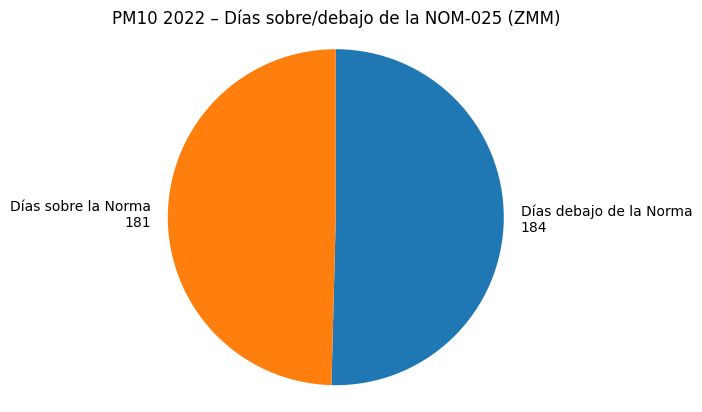

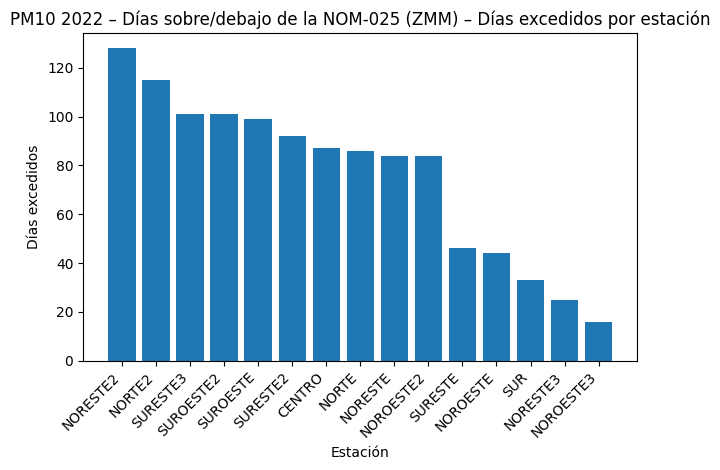

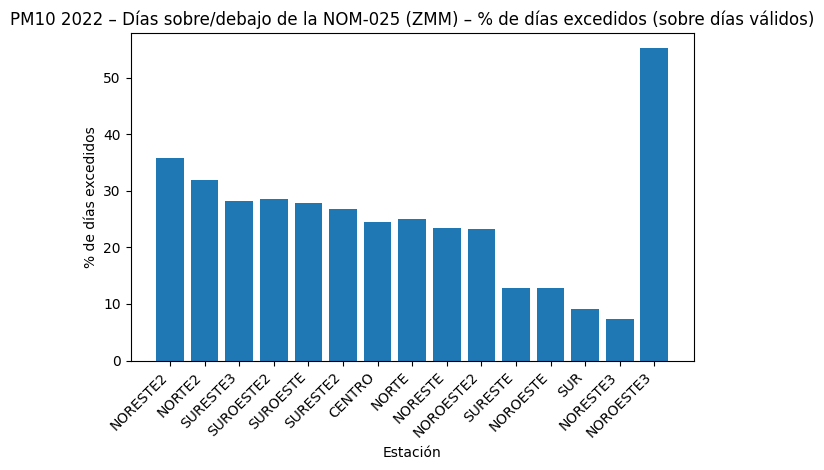

PM2.5 2022 – Días sobre/debajo de la NOM-025 (ZMM)
  Días sobre la Norma:  59
  Días debajo de la Norma: 306
  Total días evaluados (≥1 estación válida): 365


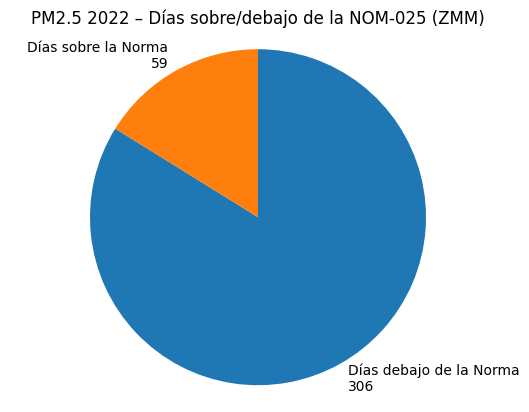

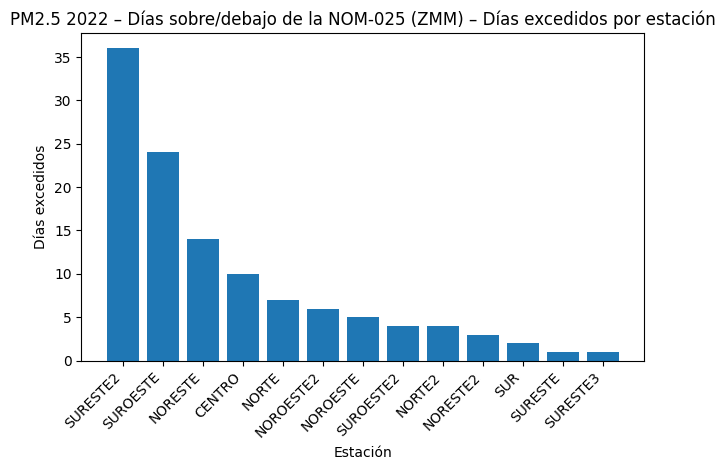

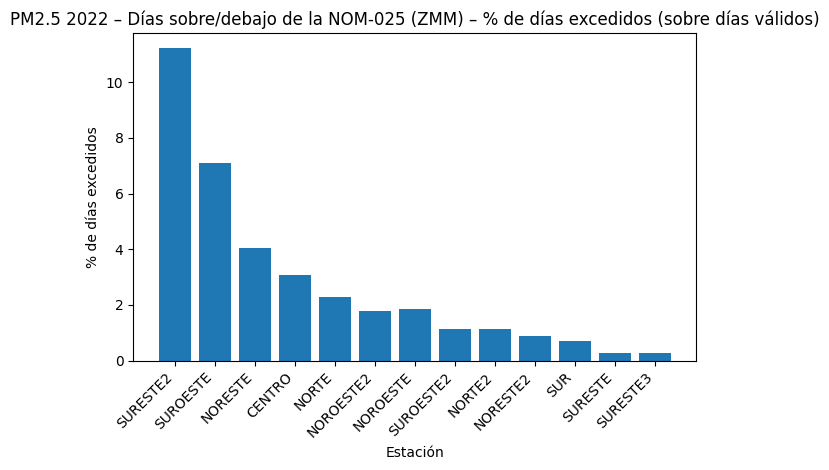

O₃ 2022 – Días con ≥1 h sobre la NOM-020 (ZMM)
  Días sobre la Norma:  77
  Días debajo de la Norma: 288
  Total días evaluados (≥1 estación válida): 365


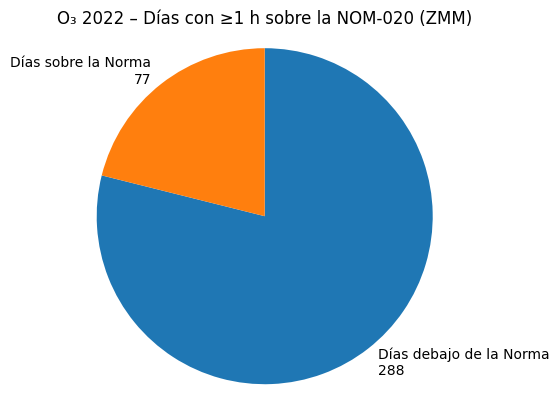

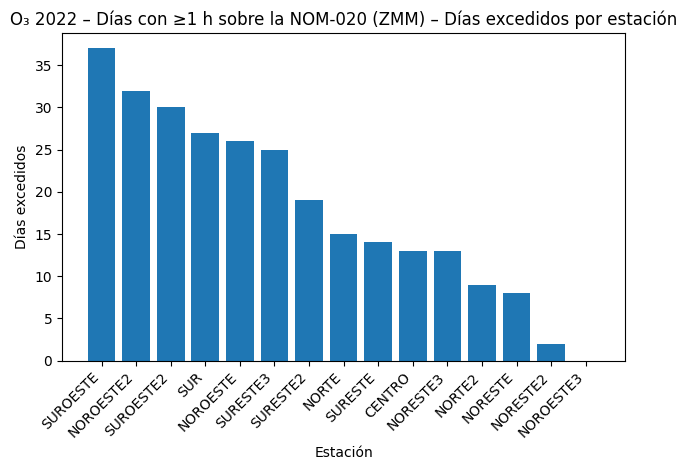

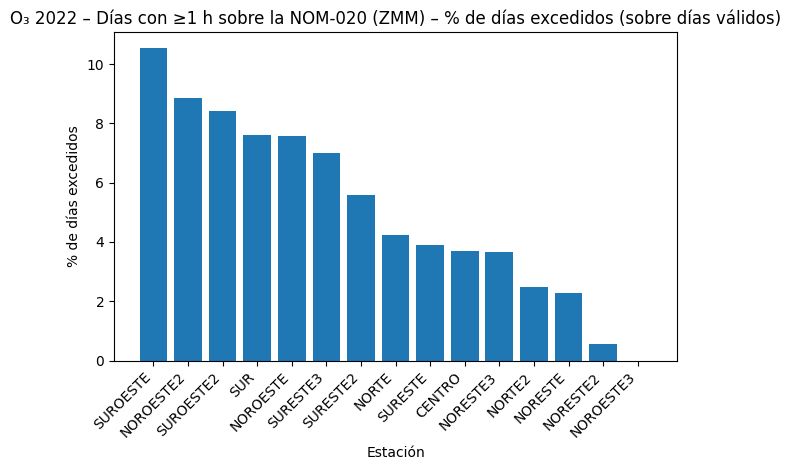

SO₂ 2022 – Días con ≥1 h sobre la NOM-022 (ZMM)
  Días sobre la Norma:  40
  Días debajo de la Norma: 325
  Total días evaluados (≥1 estación válida): 365


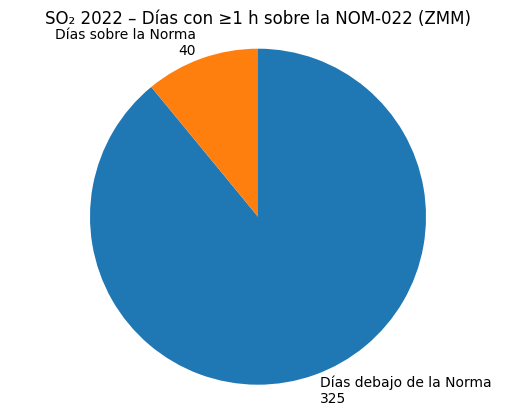

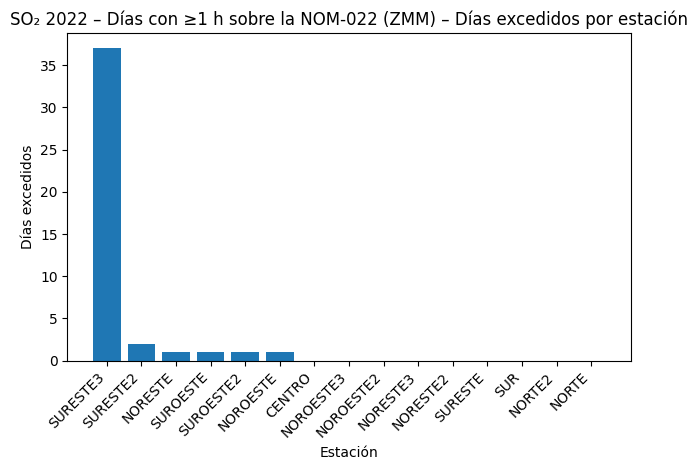

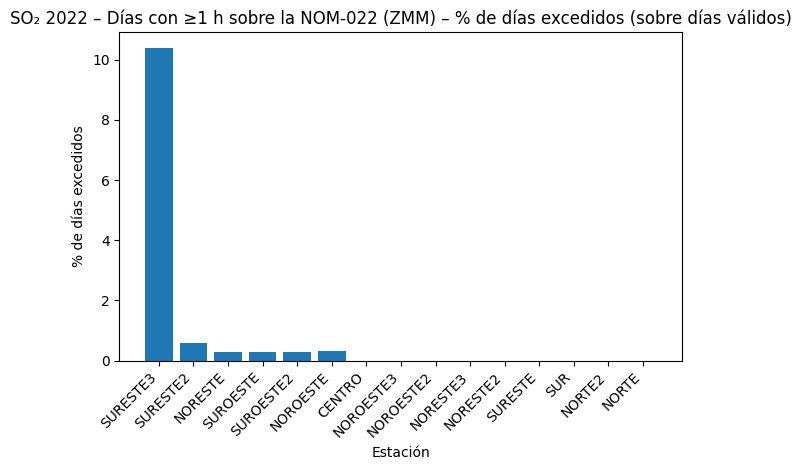

NO₂ 2022 – Días con ≥1 h sobre la NOM-023 (ZMM)
  Días sobre la Norma:  0
  Días debajo de la Norma: 365
  Total días evaluados (≥1 estación válida): 365


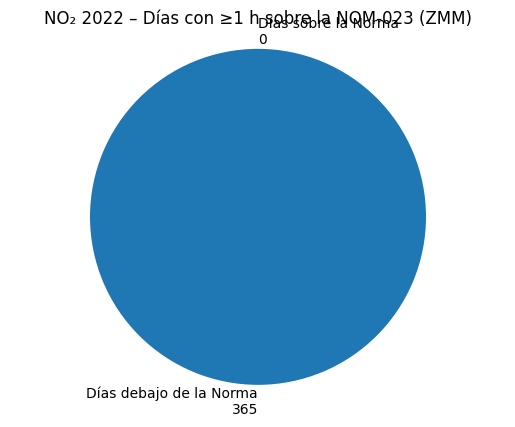

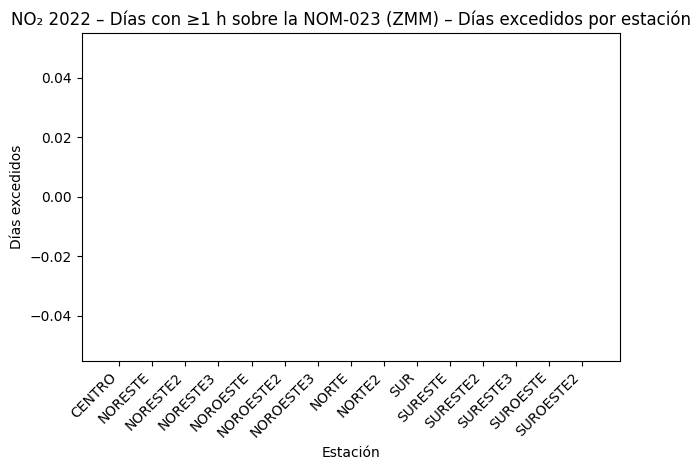

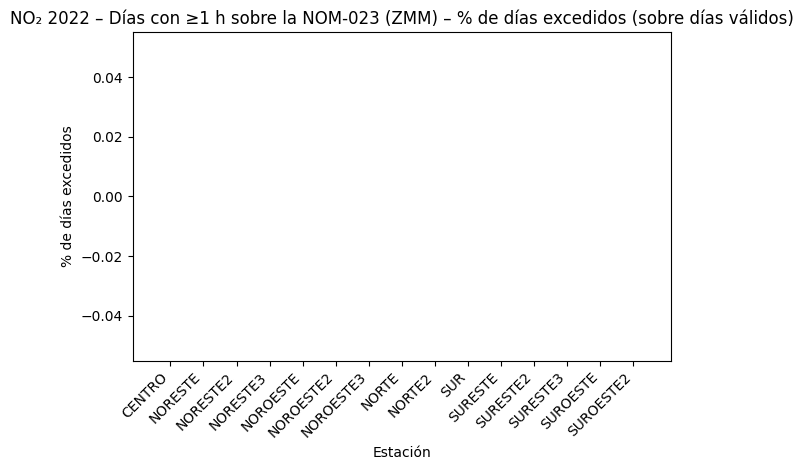

CO 2022 – Días con ≥1 h sobre la NOM-021 (ZMM)
  Días sobre la Norma:  0
  Días debajo de la Norma: 365
  Total días evaluados (≥1 estación válida): 365


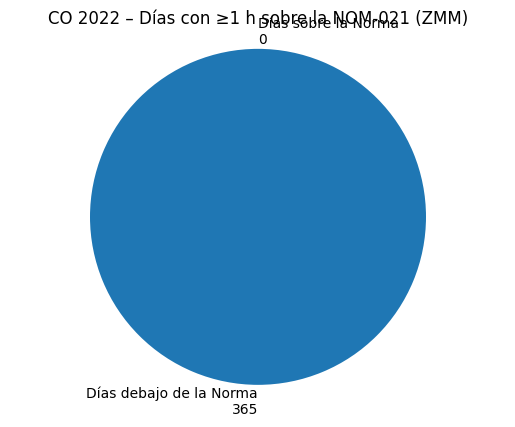

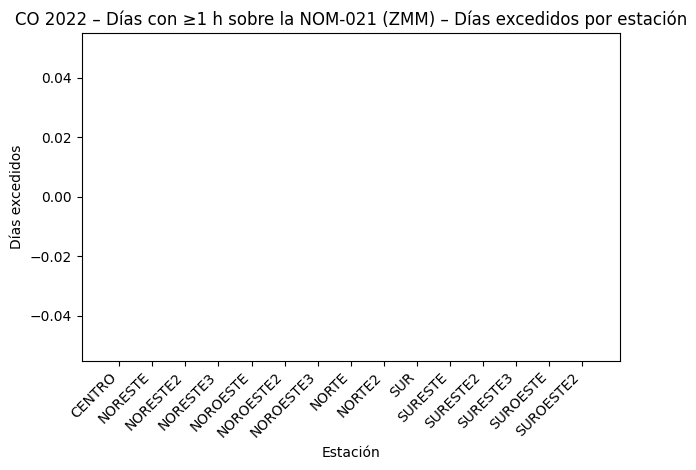

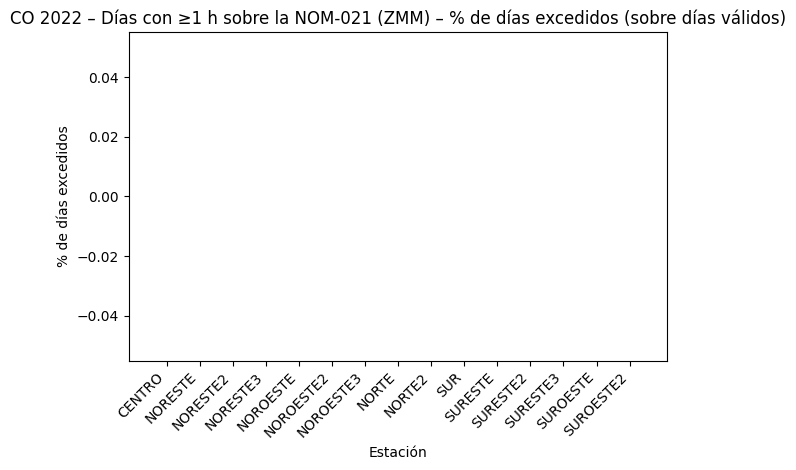


================ ZMM 2023 ================

PM10 2023 – Días sobre/debajo de la NOM-025 (ZMM)
  Días sobre la Norma:  121
  Días debajo de la Norma: 108
  Total días evaluados (≥1 estación válida): 229


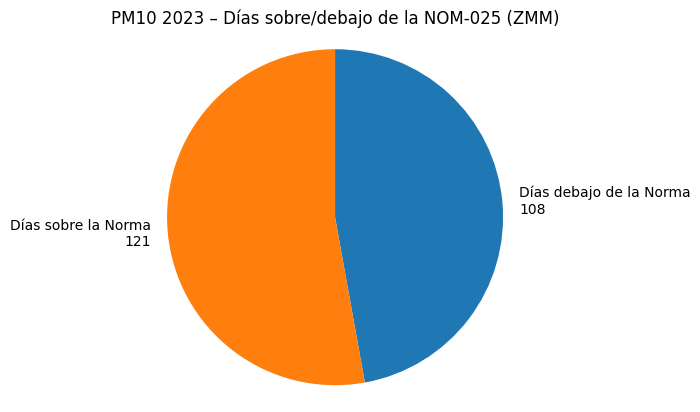

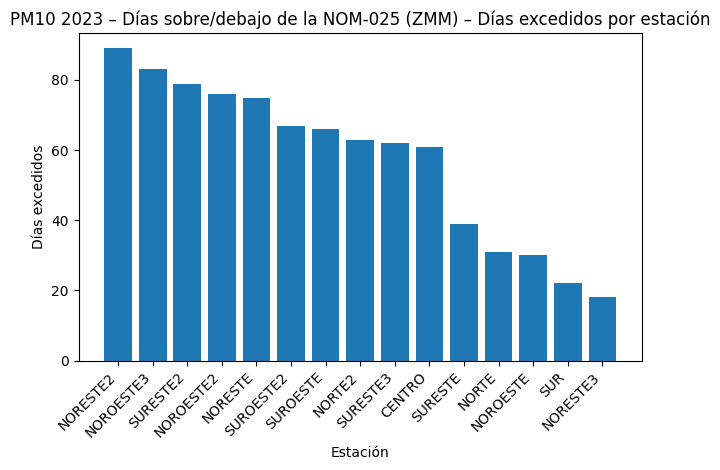

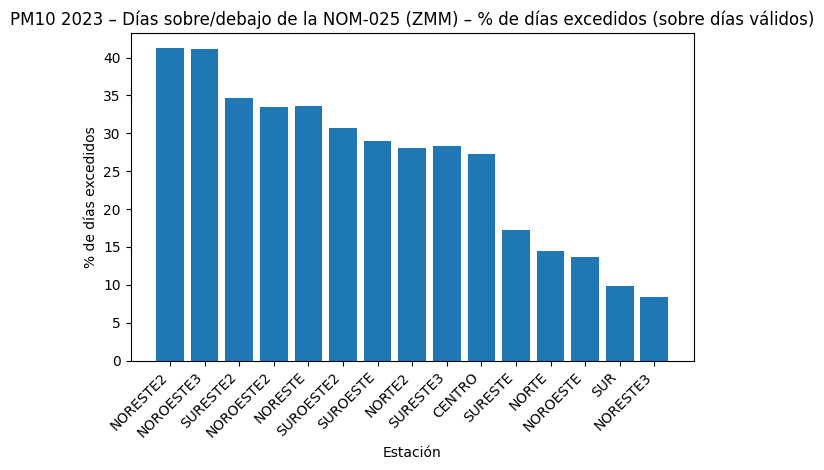

PM2.5 2023 – Días sobre/debajo de la NOM-025 (ZMM)
  Días sobre la Norma:  40
  Días debajo de la Norma: 189
  Total días evaluados (≥1 estación válida): 229


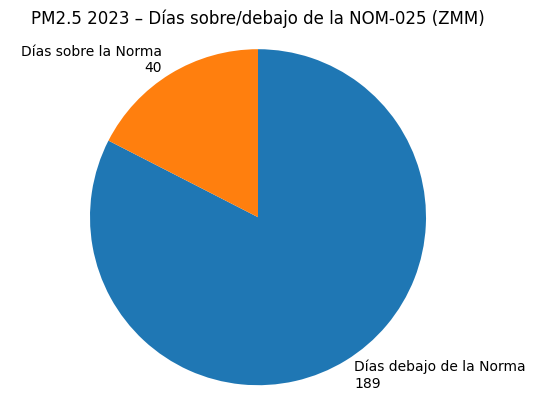

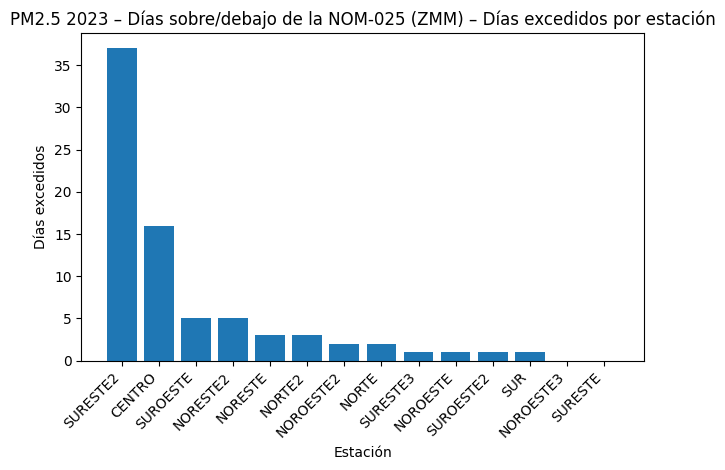

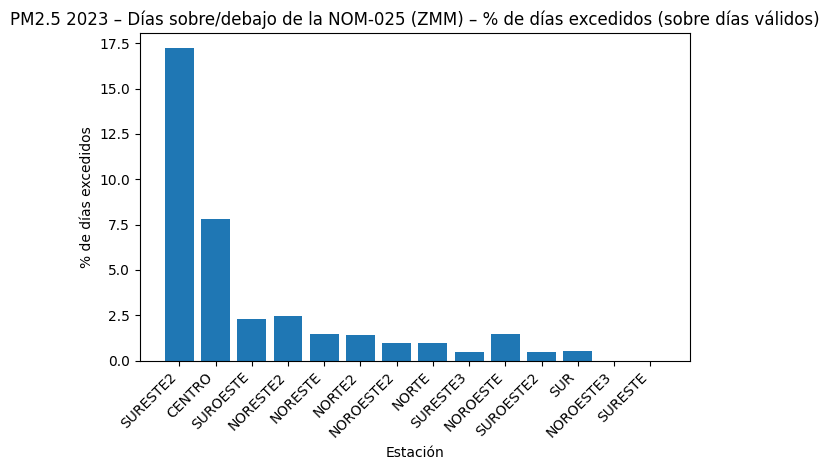

O₃ 2023 – Días con ≥1 h sobre la NOM-020 (ZMM)
  Días sobre la Norma:  43
  Días debajo de la Norma: 186
  Total días evaluados (≥1 estación válida): 229


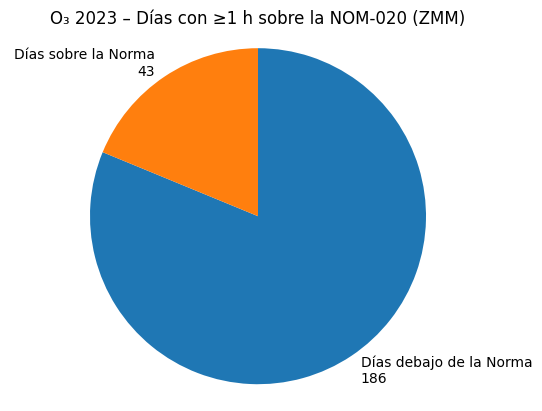

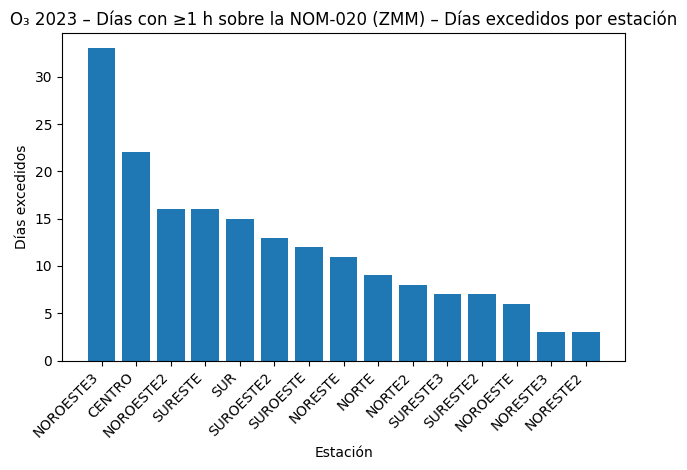

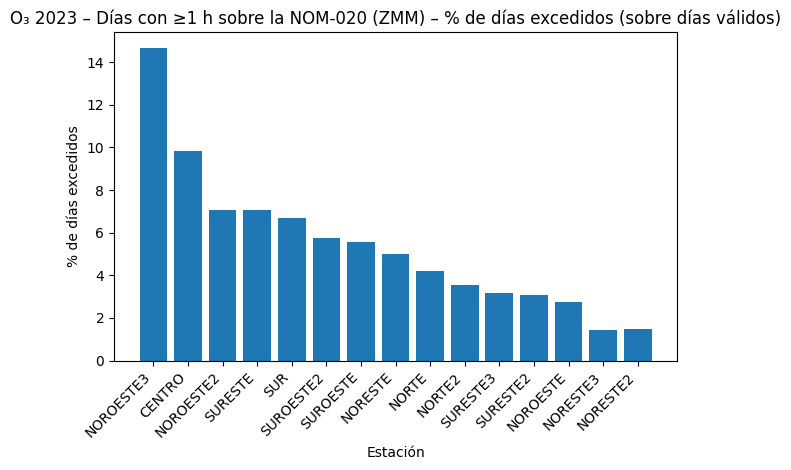

SO₂ 2023 – Días con ≥1 h sobre la NOM-022 (ZMM)
  Días sobre la Norma:  9
  Días debajo de la Norma: 220
  Total días evaluados (≥1 estación válida): 229


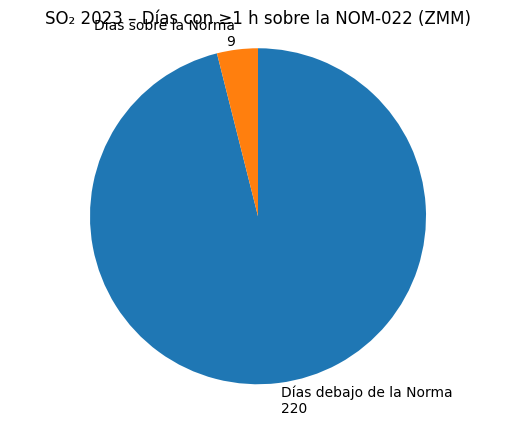

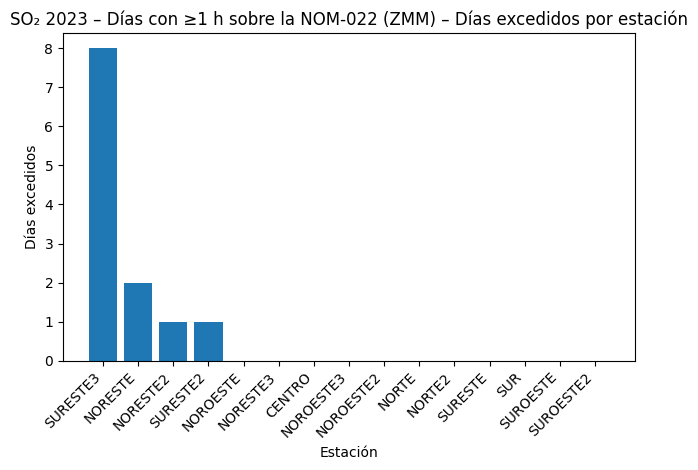

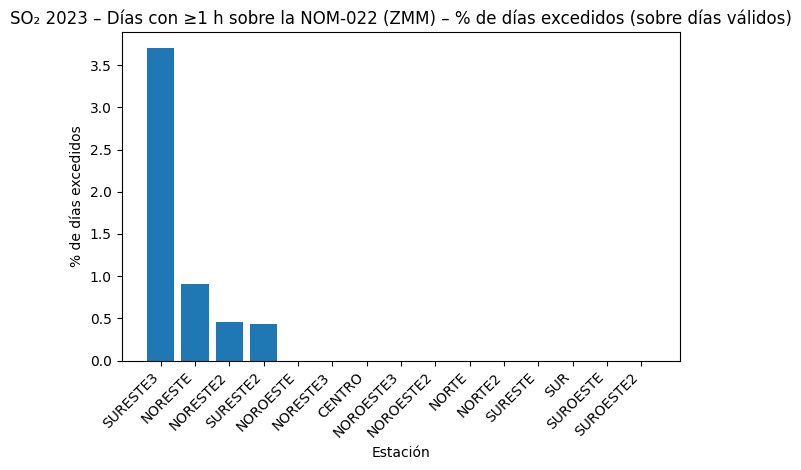

NO₂ 2023 – Días con ≥1 h sobre la NOM-023 (ZMM)
  Días sobre la Norma:  0
  Días debajo de la Norma: 229
  Total días evaluados (≥1 estación válida): 229


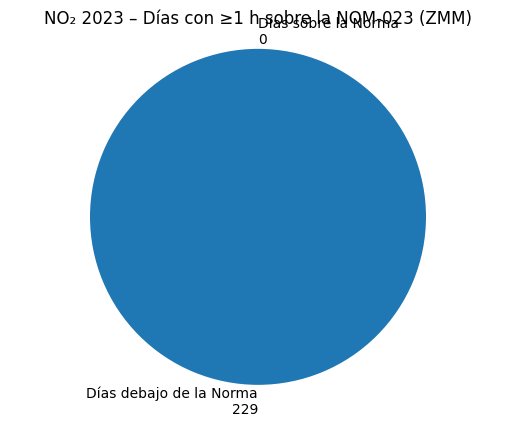

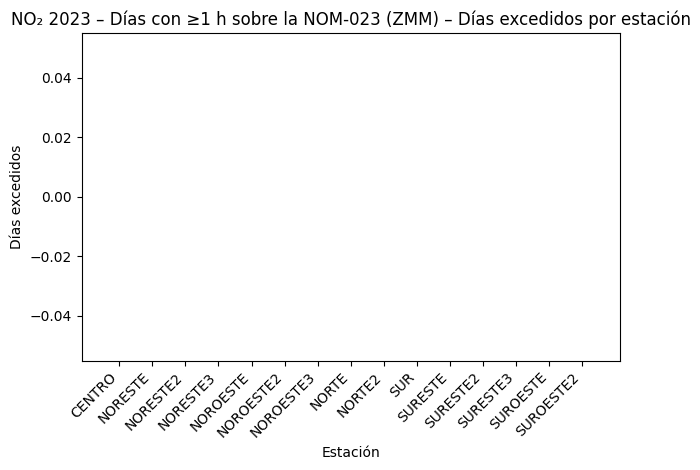

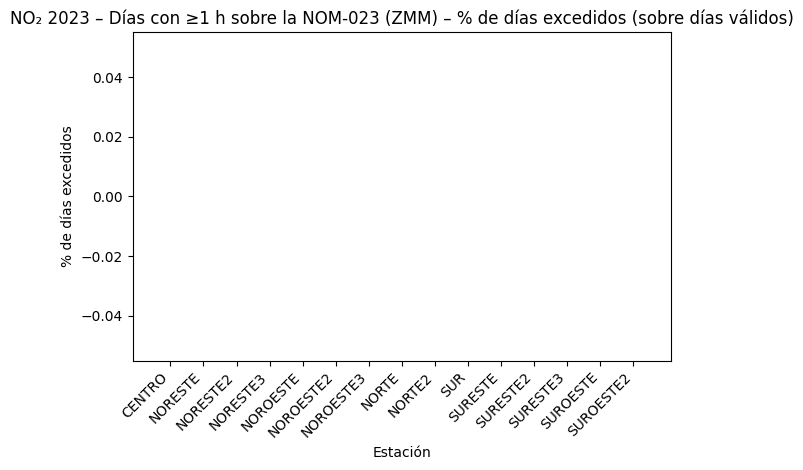

CO 2023 – Días con ≥1 h sobre la NOM-021 (ZMM)
  Días sobre la Norma:  0
  Días debajo de la Norma: 229
  Total días evaluados (≥1 estación válida): 229


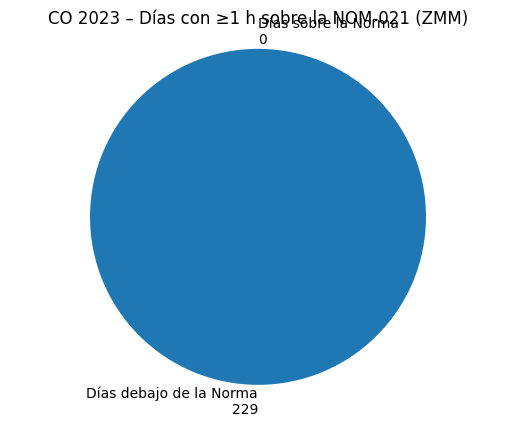

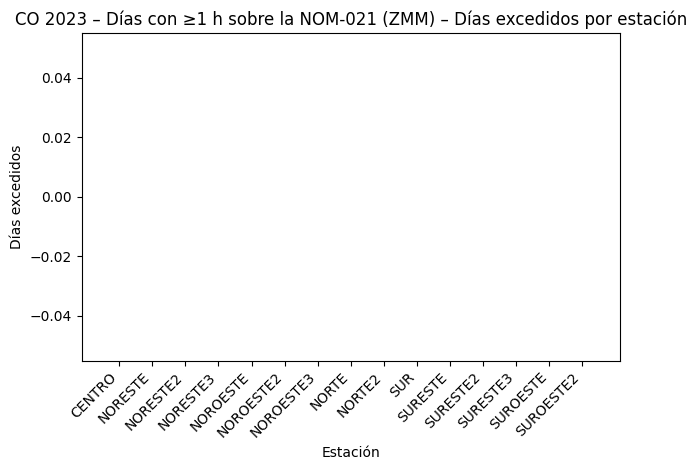

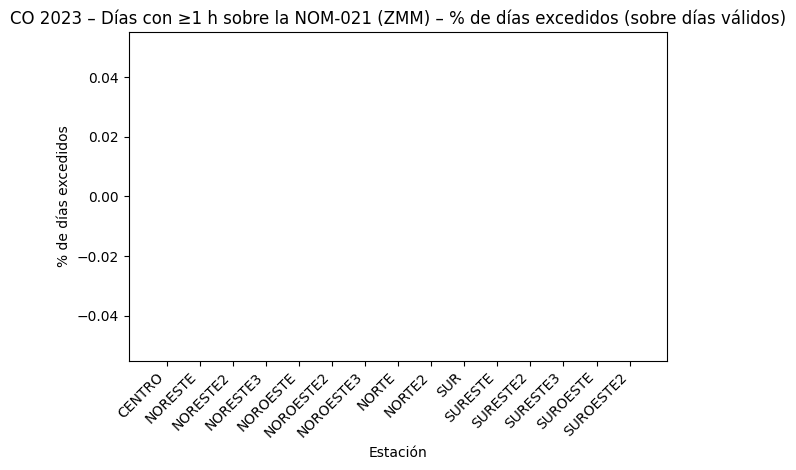

In [ ]:
# Usa un solo diccionario para 2022 y 2023
info22_23 = all_sheets2022
LIMITS = {
    "PM10": {"mode": "mean24h", "limit": 75.0,  "title": "PM10 {year} – Días sobre/debajo de la NOM-025 (ZMM)"},
    "PM2.5":{"mode": "mean24h", "limit": 45.0,  "title": "PM2.5 {year} – Días sobre/debajo de la NOM-025 (ZMM)"},
    "O3":   {"mode": "max1h",   "limit": 95.0,  "title": "O₃ {year} – Días con ≥1 h sobre la NOM-020 (ZMM)"},
    "SO2":  {"mode": "max1h",   "limit": 75.0,  "title": "SO₂ {year} – Días con ≥1 h sobre la NOM-022 (ZMM)"},
    "NO2":  {"mode": "max1h",   "limit": 210.0, "title": "NO₂ {year} – Días con ≥1 h sobre la NOM-023 (ZMM)"},
    "CO":   {"mode": "max1h",   "limit": 35.0,  "title": "CO {year} – Días con ≥1 h sobre la NOM-021 (ZMM)"},
}

for year in (2022, 2023):
    print(f"\n================ ZMM {year} ================\n")
    for label, cfg in LIMITS.items():
        key = label.lower().replace("2.5","25")   # pm2.5 -> pm25
        long_df = build_long_from_info(info22_23, year, pollutant_key=key)
        title = cfg["title"].format(year=year)
        summarize_and_plots(long_df, mode=cfg["mode"], limit=cfg["limit"], title=title)

## Análisis 2024

In [ ]:
import pandas as pd

PATH = "/content/datos2024.xlsx"
xls2024 = pd.ExcelFile(PATH)
print("Hojas:", xls2024.sheet_names)


Hojas: ['SE', 'CE', 'SO', 'NE2', 'SE2', 'SE3', 'NE', 'NO', 'NO2', 'NTE', 'NTE2', 'SO2', 'SUR', 'NO3', 'NE3']


In [ ]:
est_sureste = pd.read_excel(PATH, sheet_name="SE")
print(est_sureste.head())


         Fecha y hora  CO (ppm)  NO (ppb)  NO2 (ppb)  NOX (ppb)  O3 (ppb)  \
0 2024-01-01 00:00:00      2.08      10.5       23.3       33.8      13.0   
1 2024-01-01 01:00:00      2.07      10.5       23.4       33.9      13.0   
2 2024-01-01 02:00:00      2.36      16.9       30.0       46.9       7.0   
3 2024-01-01 03:00:00      2.11      13.6       26.6       40.1       7.0   
4 2024-01-01 04:00:00      1.94       8.5       20.6       29.2      13.0   

   PM10 (ug/m3)  PM2.5 (ug/m3)  PRS (mmHg)  RAINF (mm/h)  RH (%)  SO2 (ppb)  \
0          81.0          60.00       724.5           0.0    58.0        2.9   
1          81.0          60.52       724.5           0.0    58.0        2.9   
2          84.0            NaN       724.6           0.0    61.0        3.2   
3         132.0          64.69       724.7           0.0    62.0        3.2   
4          93.0          44.13       724.7           0.0    53.0        3.2   

   SR (kW/m2)  TOUT (ºC)  WSR (km/h)  WDR (azimutal)  
0      

In [ ]:
PATH

'/content/datos2024.xlsx'

In [ ]:
all_sheets2024 = pd.read_excel(PATH, sheet_name=None)
print(list(all_sheets2024.keys()))

['SE', 'CE', 'SO', 'NE2', 'SE2', 'SE3', 'NE', 'NO', 'NO2', 'NTE', 'NTE2', 'SO2', 'SUR', 'NO3', 'NE3']


In [ ]:
import re

def find_pollutant_col(df: pd.DataFrame, pollutant_key: str) -> str | None:
    """
    pollutant_key: 'pm10','pm25','o3','so2','no2','co'
    Ignora flags SOLO si el nombre original termina en '_b'.
    Acepta encabezados con unidades (ej. 'O3 (ppb)', 'PM10 (ug/m3)').
    """
    def is_flag(colname: str) -> bool:
        return bool(re.search(r"_b\s*$", str(colname).strip(), flags=re.IGNORECASE))
    pk = _norm(pollutant_key)
    for c in df.columns:
        if is_flag(c):
            continue
        cn = _norm(c)
        if cn in {"parameter","parametro"}:
            continue
        if cn == pk:
            return c
    for c in df.columns:
        if is_flag(c):
            continue
        cn = _norm(c)
        if cn in {"parameter","parametro"}:
            continue
        if pk in cn:
            return c

    return None


PM10 2024 – Días sobre/debajo de la NOM-025 (ZMM)
  Días sobre la Norma:  207
  Días debajo de la Norma: 159
  Total días evaluados (≥1 estación válida): 366


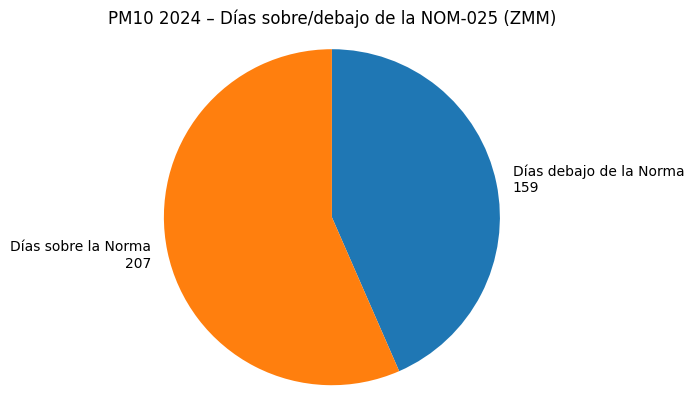

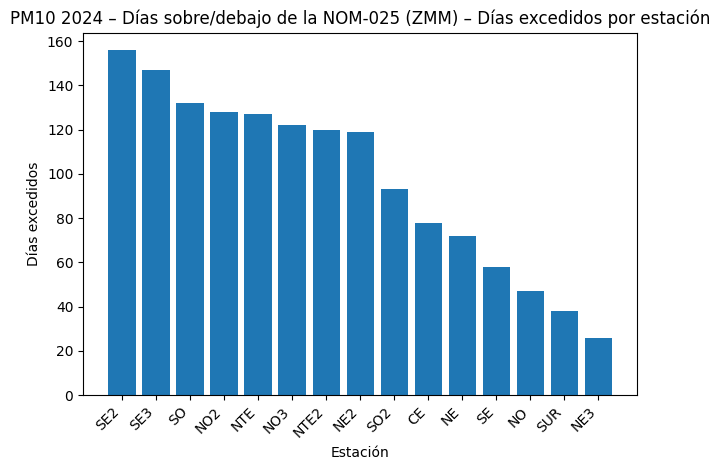

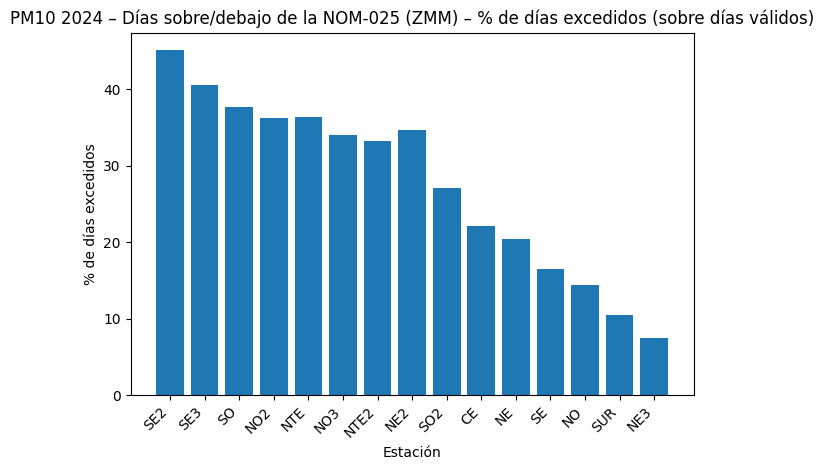

PM2.5 2024 – Días sobre/debajo de la NOM-025 (ZMM)
  Días sobre la Norma:  69
  Días debajo de la Norma: 297
  Total días evaluados (≥1 estación válida): 366


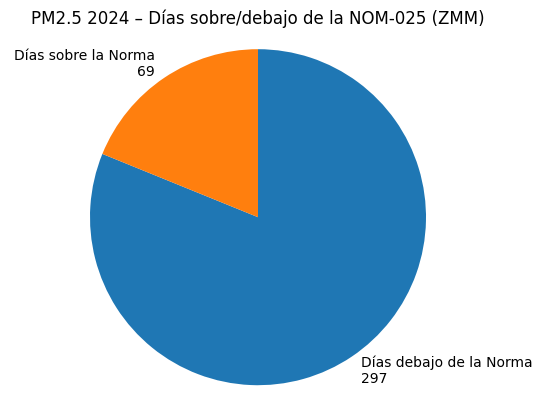

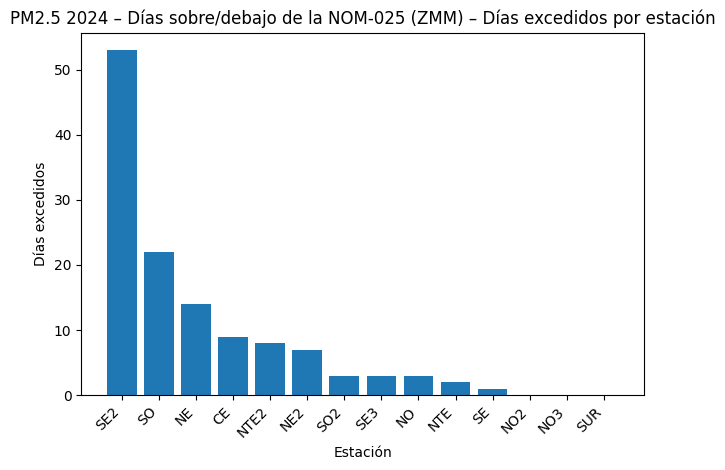

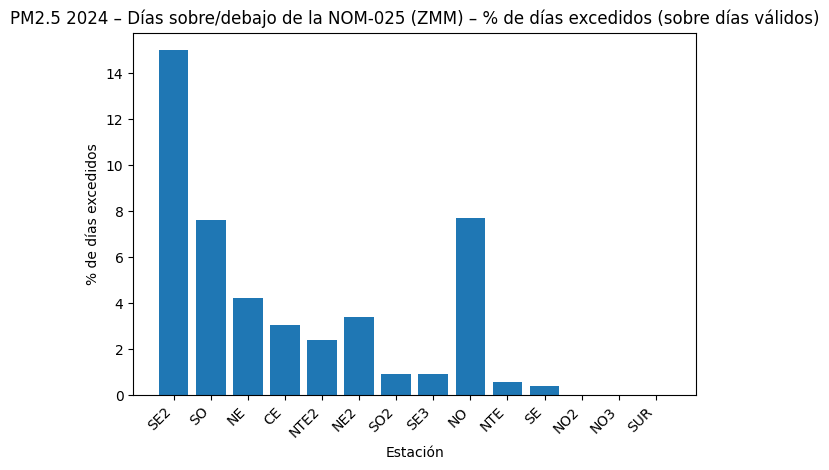

O₃ 2024 – Días con ≥1 h sobre la NOM-020 (ZMM)
  Días sobre la Norma:  95
  Días debajo de la Norma: 271
  Total días evaluados (≥1 estación válida): 366


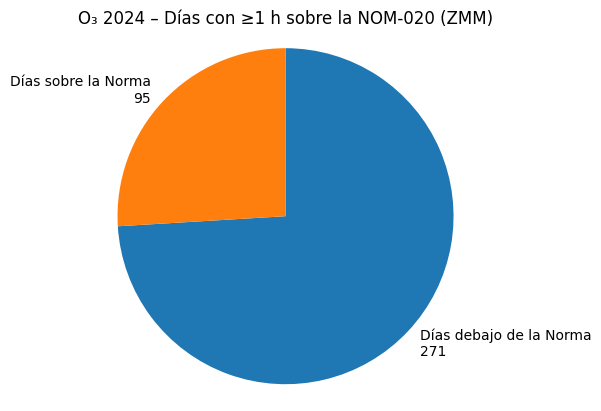

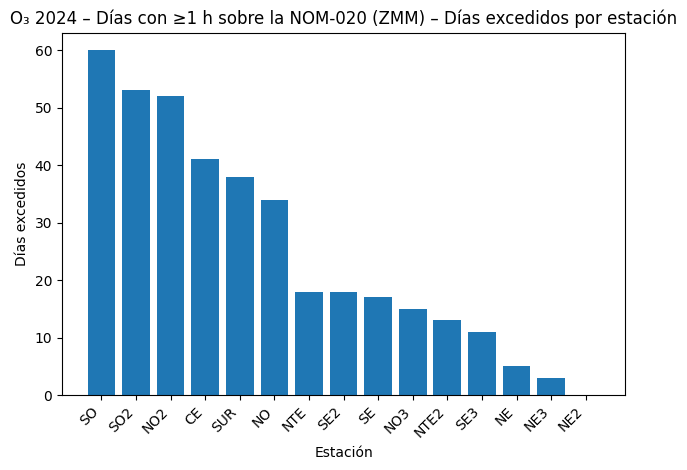

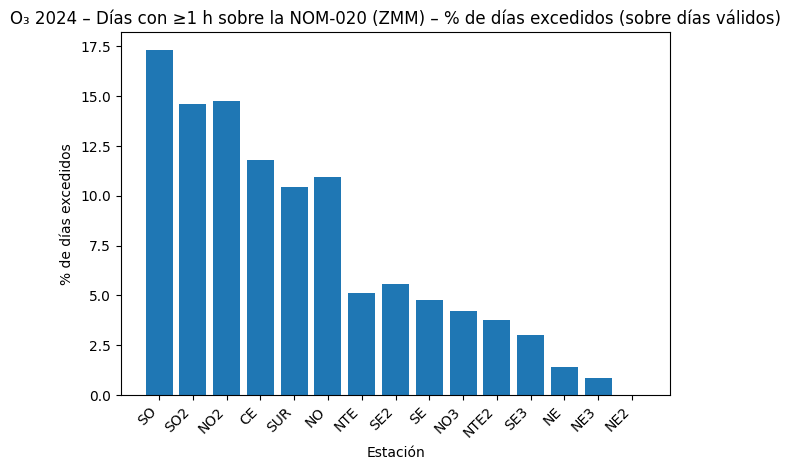

SO₂ 2024 – Días con ≥1 h sobre la NOM-022 (ZMM)
  Días sobre la Norma:  19
  Días debajo de la Norma: 347
  Total días evaluados (≥1 estación válida): 366


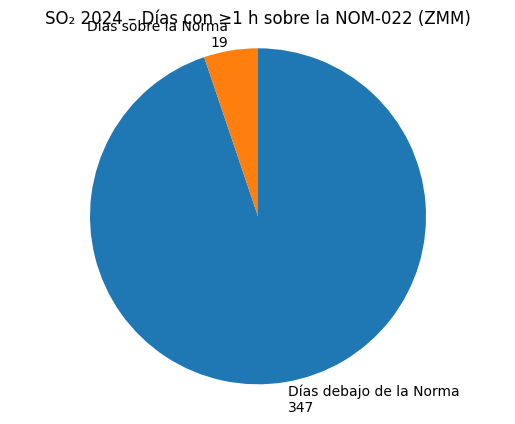

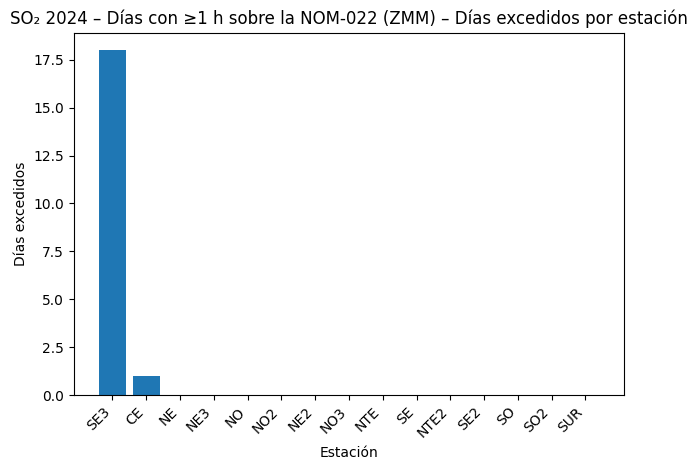

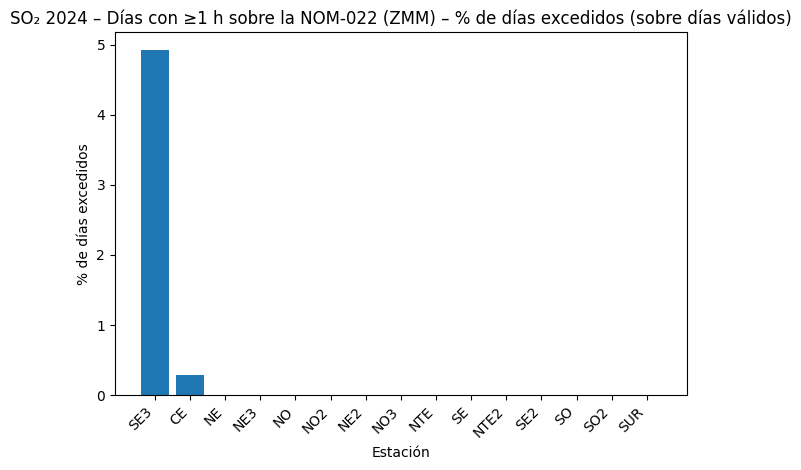

NO₂ 2024 – Días con ≥1 h sobre la NOM-023 (ZMM)
  Días sobre la Norma:  0
  Días debajo de la Norma: 366
  Total días evaluados (≥1 estación válida): 366


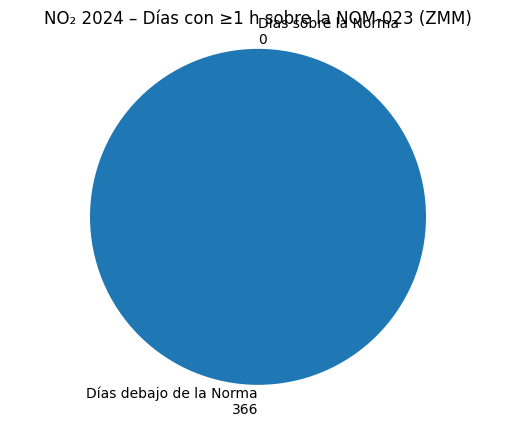

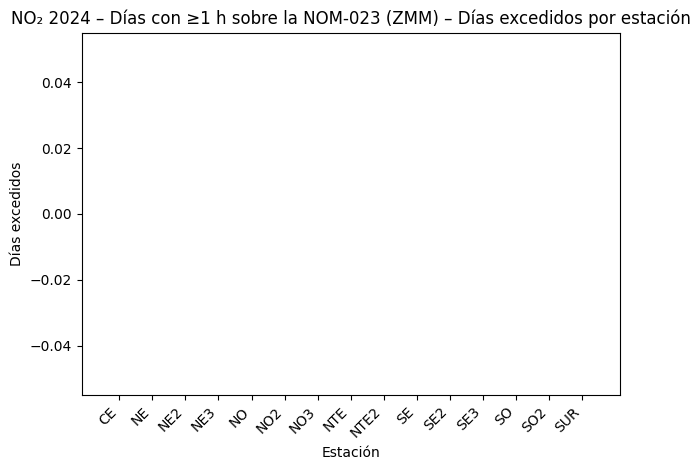

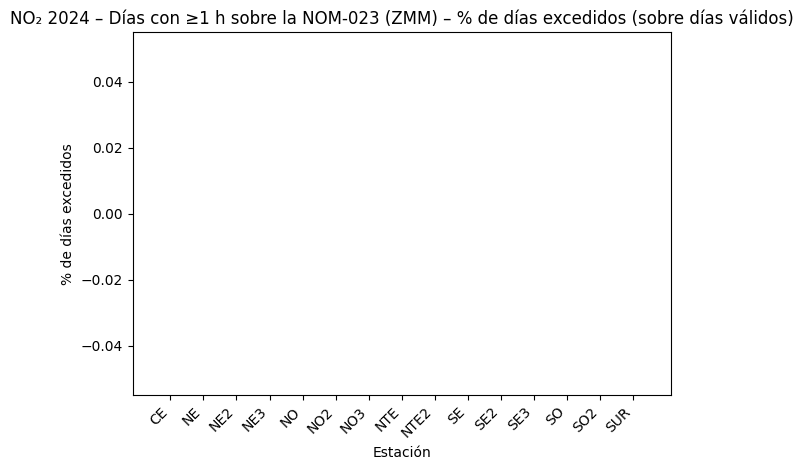

CO 2024 – Días con ≥1 h sobre la NOM-021 (ZMM)
  Días sobre la Norma:  1
  Días debajo de la Norma: 365
  Total días evaluados (≥1 estación válida): 366


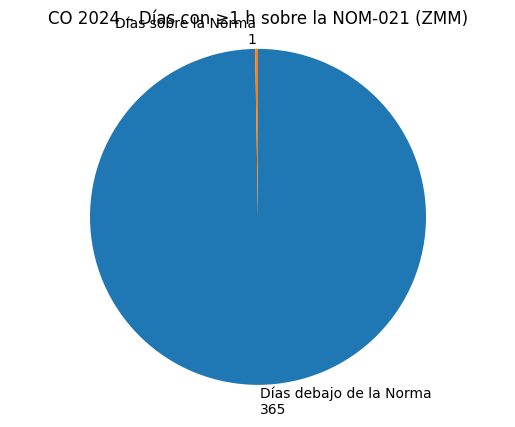

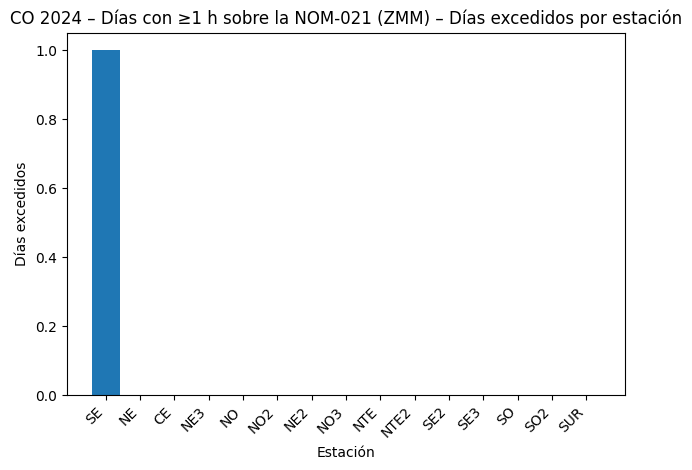

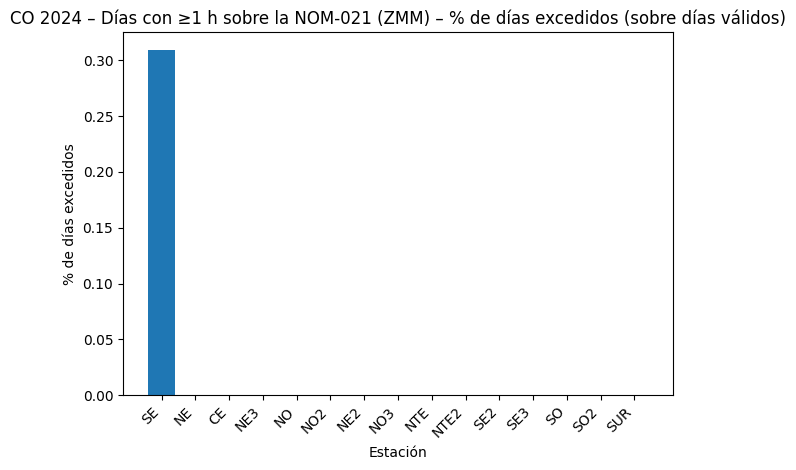

In [ ]:
YEAR = 2024
for label, cfg in LIMITS.items():
    key = label.lower().replace("2.5","25")
    long_df = build_long_from_info(info2024, YEAR, pollutant_key=key)
    summarize_and_plots(long_df, mode=cfg["mode"], limit=cfg["limit"], title=cfg["title"])

## Análisis 2025


In [ ]:
import pandas as pd
PATH = "/content/datos2025.xlsx"
xls2025 = pd.ExcelFile(PATH)
print("Hojas:", xls2025.sheet_names)

Hojas: ['Variables', 'Observaciones']


In [ ]:
est_sureste = pd.read_excel(PATH, sheet_name="Observaciones")
print(est_sureste.head())


  Unnamed: 0                                Puntos importantes:
0         1)  El equipo de la estación Noroeste se dañó por ...
1         2)  Hay algunos episodios donde los picos de conce...
2         3)  Los valores de PM10 contemplan los valores de ...
3         4)  En los sensores Norte, Norte 2, Noreste, Sures...


In [ ]:
all_sheets2024 = pd.read_excel(PATH, sheet_name=None)
print(list(all_sheets.keys()))

['SURESTE', 'NORESTE', 'CENTRO', 'NOROESTE', 'SUROESTE', 'NOROESTE2', 'NORTE', 'SUROESTE2', 'SURESTE2', 'SURESTE3', 'SUR', 'NORTE2', 'NORESTE2', 'NORESTE3', 'NOROESTE3', 'CATÁLOGO']


    año  días excedidos  días evaluados  % días excedidos
0  2020             153             366         41.803279
1  2021             190             365         52.054795
2  2022             181             365         49.589041
3  2023             121             229         52.838428
4  2024             207             366         56.557377


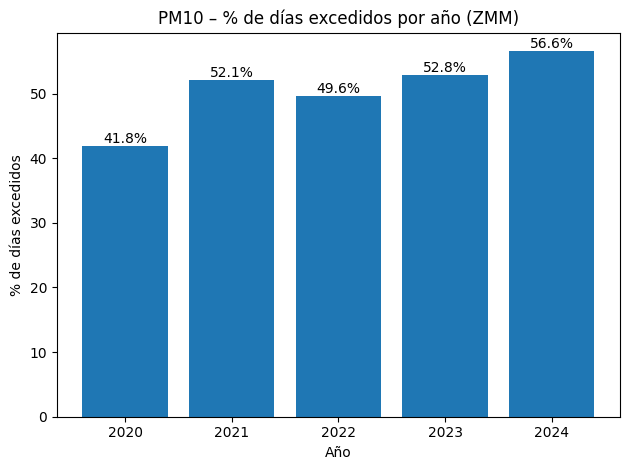

In [ ]:
import re, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
PM10_LIMIT = 75.0

def _norm(s: str) -> str:
    s = str(s).lower()
    s = (s.replace("á","a").replace("é","e").replace("í","i")
           .replace("ó","o").replace("ú","u")
           .replace("pm2.5","pm25").replace("pm2_5","pm25"))
    s = re.sub(r"[^a-z0-9]", "", s)
    return s

def find_datetime_col(df: pd.DataFrame) -> str:
    m = {c.lower(): c for c in df.columns}
    for k in ["fecha y hora","date","fecha","datetime","time","hora","timestamp"]:
        if k in m: return m[k]
    for c in df.columns:
        if np.issubdtype(df[c].dtype, np.datetime64): return c
    return df.columns[0]

def find_pollutant_col(df: pd.DataFrame, pollutant_key: str) -> str | None:
    """Detecta 'pm10' aun cuando venga con unidades ('PM10 (ug/m3)'); solo ignora columnas *_b."""
    def is_flag(colname: str) -> bool:
        return bool(re.search(r"_b\s*$", str(colname).strip(), flags=re.IGNORECASE))
    pk = _norm(pollutant_key)
    for c in df.columns:
        if is_flag(c): continue
        cn = _norm(c)
        if cn in {"parameter","parametro"}: continue
        if cn == pk: return c
    for c in df.columns:
        if is_flag(c): continue
        cn = _norm(c)
        if cn in {"parameter","parametro"}: continue
        if pk in cn: return c
    return None

def completeness_threshold(nmax: int) -> int:
    return 1 if nmax <= 1 else math.ceil(0.75 * nmax)
def build_long_from_info(info_dict, year, pollutant_key="pm10"):
    """info_dict: dict(nombre_hoja_estacion -> DataFrame) -> long_df con timestamp/fecha/estacion/valor."""
    frames, skipped = [], []
    for station_name, df in info_dict.items():
        if not isinstance(df, pd.DataFrame) or df.empty:
            continue
        if _norm(station_name) in {"catalogo","catalogohoja","catalogo1"}:
            continue
        tcol = find_datetime_col(df)
        pcol = find_pollutant_col(df, pollutant_key)
        if pcol is None:
            skipped.append(station_name); continue
        tmp = df[[tcol, pcol]].copy()
        tmp[tcol] = pd.to_datetime(tmp[tcol], errors="coerce")
        tmp = tmp.dropna(subset=[tcol])
        tmp = tmp[tmp[tcol].dt.year == year]
        if tmp.empty:
            continue
        tmp[pcol] = pd.to_numeric(tmp[pcol], errors="coerce")
        tmp = tmp.dropna(subset=[pcol])
        if tmp.empty:
            continue
        out = pd.DataFrame({
            "timestamp": tmp[tcol].values,
            "estacion": station_name,
            "valor": tmp[pcol].values
        })
        out["fecha"] = pd.to_datetime(out["timestamp"]).dt.date
        frames.append(out)
    if not frames:
        raise ValueError(f"No se encontró '{pollutant_key}' en estaciones para {year}. Omitidas: {sorted(skipped)}")
    return pd.concat(frames, ignore_index=True)

def percent_exceeded_pm10(info_dict, year, limit=PM10_LIMIT):
    """Devuelve (dias_excedidos, dias_evaluados, pct) para el año dado."""
    long_df = build_long_from_info(info_dict, year, pollutant_key="pm10")

    spd = long_df.groupby(["estacion","fecha"], as_index=False).agg(n=("valor","size"))
    nmax = spd.groupby("estacion", as_index=False)["n"].max().rename(columns={"n":"n_max"})
    df2 = long_df.merge(nmax, on="estacion", how="left")
    daily = (df2.groupby(["estacion","fecha"], as_index=False)
             .agg(media=("valor","mean"), n=("valor","size"), n_max=("n_max","max")))
    daily["min_validos"] = daily["n_max"].apply(completeness_threshold)
    daily["dia_valido"]  = daily["n"] >= daily["min_validos"]
    daily["excede"]      = (daily["dia_valido"]) & (daily["media"] > limit)

    daily_valid = daily[daily["dia_valido"]].copy()
    zmm = (daily_valid.assign(any_exceso=lambda d: d["media"] > limit)
           .groupby("fecha", as_index=False).agg(hay_exceso=("any_exceso","max")))
    dias_excedidos = int(zmm["hay_exceso"].sum())
    dias_eval      = int(len(zmm))
    pct            = 100.0 * dias_excedidos / dias_eval if dias_eval > 0 else np.nan
    return dias_excedidos, dias_eval, pct

def _first_defined(*names):
    for n in names:
        if n in globals():
            return globals()[n]
    return None

info_by_year = {}
d20_21 = _first_defined("all_sheets", "info2020")
if d20_21 is not None:
    info_by_year[2020] = d20_21
    info_by_year[2021] = d20_21
d22_23 = _first_defined("all_sheets2022", "info22_23")
if d22_23 is not None:
    info_by_year[2022] = d22_23
    info_by_year[2023] = d22_23
d2024 = _first_defined("all_sheets2024")
if d2024 is not None:
    info_by_year[2024] = d2024
d2025 = _first_defined("all_sheets2025")
if d2025 is not None:
    info_by_year[2025] = d2025

rows = []
for year in sorted(info_by_year.keys()):
    dias_exc, dias_eval, pct = percent_exceeded_pm10(info_by_year[year], year, limit=PM10_LIMIT)
    rows.append({"año": year, "días excedidos": dias_exc, "días evaluados": dias_eval, "% días excedidos": pct})

res = pd.DataFrame(rows).sort_values("año")
print(res)
plt.figure()
plt.bar(res["año"].astype(str), res["% días excedidos"])
plt.title("PM10 – % de días excedidos por año (ZMM)")
plt.ylabel("% de días excedidos")
plt.xlabel("Año")
for i, v in enumerate(res["% días excedidos"]):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()


In [ ]:
INFO = all_sheets2024
YEAR = 2024



PM10 2020 – Resumen por estación del año (ZMM)


,season,dias_excedidos,dias_evaluados,% excedidos
0,Invierno,59,91,64.835165
2,Primavera,27,92,29.347826
3,Verano,15,92,16.304348
1,Otoño,52,91,57.142857


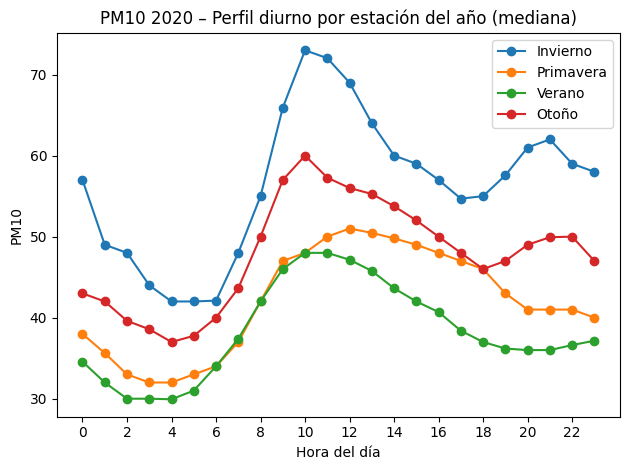

/tmp/ipython-input-665207820.py:134: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = [float(seas_df.loc[seas_df["season"]==s, "% excedidos"]) if s in set(seas_df["season"]) else np.nan for s in x]


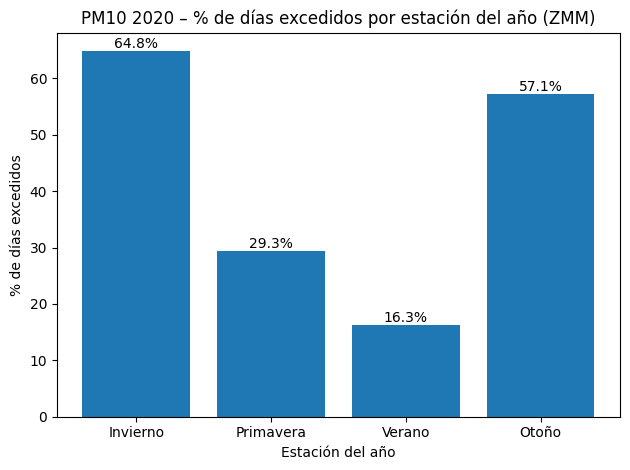


PM2.5 2020 – Resumen por estación del año (ZMM)


,season,dias_excedidos,dias_evaluados,% excedidos
0,Invierno,21,91,23.076923
2,Primavera,8,92,8.695652
3,Verano,1,92,1.086957
1,Otoño,7,91,7.692308


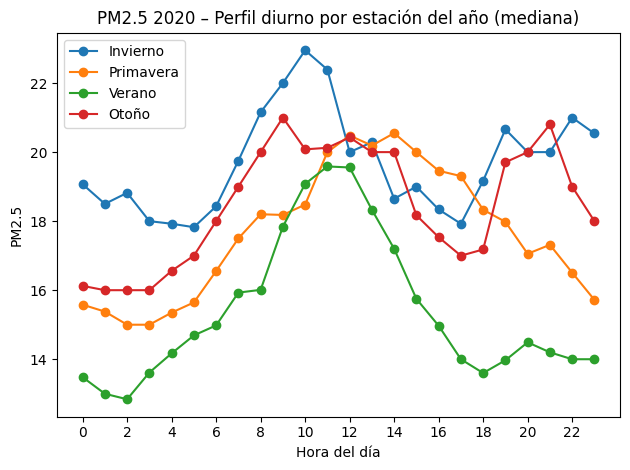

/tmp/ipython-input-665207820.py:134: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = [float(seas_df.loc[seas_df["season"]==s, "% excedidos"]) if s in set(seas_df["season"]) else np.nan for s in x]


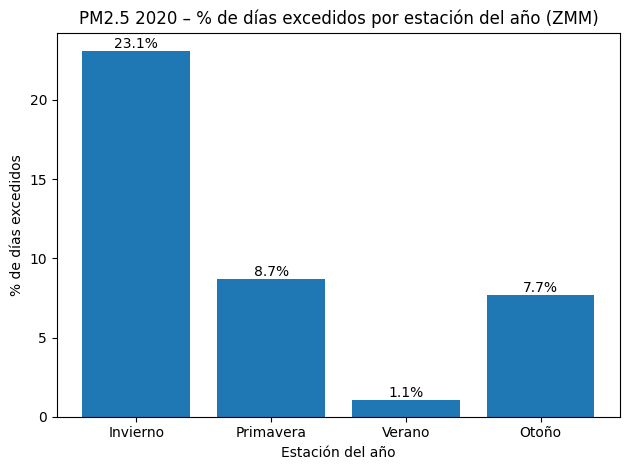


O₃ 2020 – Resumen por estación del año (ZMM)


,season,dias_excedidos,dias_evaluados,% excedidos
0,Invierno,9,91,9.890110
2,Primavera,18,92,19.565217
3,Verano,16,92,17.391304
1,Otoño,19,91,20.879121


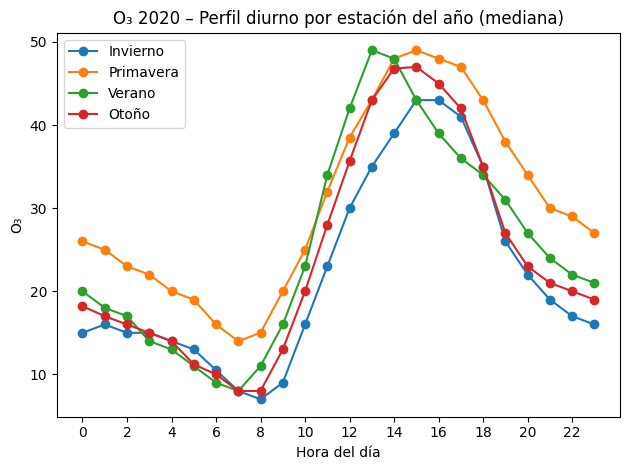

/tmp/ipython-input-665207820.py:134: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = [float(seas_df.loc[seas_df["season"]==s, "% excedidos"]) if s in set(seas_df["season"]) else np.nan for s in x]


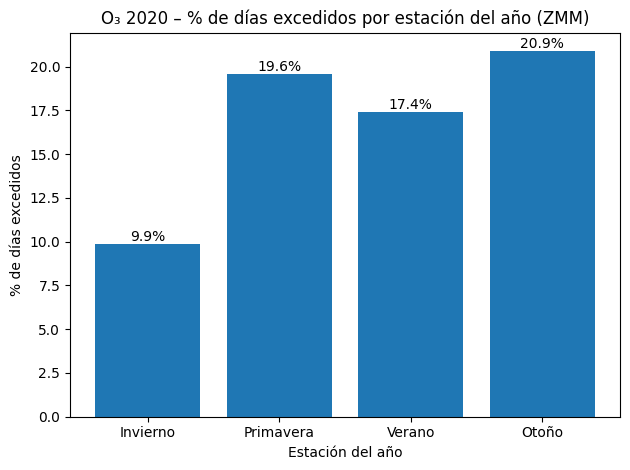

In [ ]:
import re, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INFO = all_sheets
YEAR = 2020
LIMITS = {
    "pm10": {"mode": "mean24h", "limit": 75.0, "title": "PM10"},
    "pm25": {"mode": "mean24h", "limit": 45.0, "title": "PM2.5"},
    "o3":   {"mode": "max1h",   "limit": 95.0, "title": "O₃"},
}

SEASON_ORDER = ["Invierno", "Primavera", "Verano", "Otoño"]

def month_to_season(m: int) -> str:
    if m in (12, 1, 2):  return "Invierno"
    if m in (3, 4, 5):   return "Primavera"
    if m in (6, 7, 8):   return "Verano"
    return "Otoño"

def _norm(s):
    s = str(s).lower()
    s = (s.replace("á","a").replace("é","e").replace("í","i")
           .replace("ó","o").replace("ú","u")
           .replace("pm2.5","pm25").replace("pm2_5","pm25"))
    return re.sub(r"[^a-z0-9]", "", s)
def find_datetime_col(df):
    m = {c.lower(): c for c in df.columns}
    for k in ["fecha y hora","date","fecha","datetime","time","hora","timestamp"]:
        if k in m: return m[k]
    for c in df.columns:
        if np.issubdtype(df[c].dtype, np.datetime64): return c
    return df.columns[0]
def find_pollutant_col(df, key):
    def is_flag(c): return bool(re.search(r"_b\s*$", str(c).strip(), flags=re.I))
    pk = _norm(key)
    for c in df.columns:
        if is_flag(c): continue
        if _norm(c) == pk: return c
    for c in df.columns:
        if is_flag(c): continue
        if pk in _norm(c): return c
    return None

def completeness_threshold(nmax):
    return 1 if nmax <= 1 else math.ceil(0.75*nmax)
def long_from_info(info_dict, year, pollutant_key):
    frames = []
    for est, df in info_dict.items():
        if not isinstance(df, pd.DataFrame) or df.empty: continue
        if _norm(est) in {"catalogo","catalogohoja","catalogo1"}: continue
        tcol = find_datetime_col(df); pcol = find_pollutant_col(df, pollutant_key)
        if pcol is None: continue
        tmp = df[[tcol,pcol]].copy()
        tmp[tcol] = pd.to_datetime(tmp[tcol], errors="coerce")
        tmp = tmp.dropna(subset=[tcol])
        tmp = tmp[tmp[tcol].dt.year == year]
        if tmp.empty: continue
        tmp[pcol] = pd.to_numeric(tmp[pcol], errors="coerce")
        tmp = tmp.dropna(subset=[pcol])
        if tmp.empty: continue
        out = pd.DataFrame({
            "timestamp": tmp[tcol].values,
            "estacion": est,
            "valor": tmp[pcol].values
        })
        out["dt"]     = pd.to_datetime(out["timestamp"])
        out["fecha"]  = out["dt"].dt.date
        out["hora"]   = out["dt"].dt.hour
        out["season"] = out["dt"].dt.month.map(month_to_season)
        frames.append(out)
    if not frames:
        raise ValueError(f"No hay datos para {pollutant_key} en {year}.")
    return pd.concat(frames, ignore_index=True)

def keep_valid_days(long_df):
    n_day = long_df.groupby(["estacion","fecha"], as_index=False).agg(n=("valor","size"))
    nmax  = n_day.groupby("estacion", as_index=False)["n"].max().rename(columns={"n":"n_max"})
    n_day = n_day.merge(nmax, on="estacion", how="left")
    n_day["min_validos"] = n_day["n_max"].apply(completeness_threshold)
    n_day["dia_valido"]  = n_day["n"] >= n_day["min_validos"]
    return long_df.merge(n_day[["estacion","fecha","dia_valido"]], on=["estacion","fecha"], how="left")\
                  .query("dia_valido").copy()

def daily_aggregate_and_exceedances(valid_long, mode, limit):
    if mode == "mean24h":
        daily = (valid_long.groupby(["estacion","fecha","season"], as_index=False)
                 .agg(agregado=("valor","mean")))
    elif mode == "max1h":
        daily = (valid_long.groupby(["estacion","fecha","season"], as_index=False)
                 .agg(agregado=("valor","max")))
    else:
        raise ValueError("mode debe ser 'mean24h' o 'max1h'.")

    daily["excede"] = daily["agregado"] > limit
    zmm = (daily.groupby(["fecha","season"], as_index=False)
           .agg(hay_exceso=("excede","max")))
    seas = (zmm.groupby("season", as_index=False)
            .agg(dias_excedidos=("hay_exceso","sum"),
                 dias_evaluados=("hay_exceso","size")))
    seas["% excedidos"] = 100 * seas["dias_excedidos"] / seas["dias_evaluados"]
    seas["order"] = seas["season"].map({s:i for i,s in enumerate(SEASON_ORDER)})
    return daily, seas.sort_values("order").drop(columns=["order"])

def plot_diurnal_by_season(valid_long, pol_title, year):
    diur = (valid_long.groupby(["season","hora"])["valor"]
            .agg(mediana="median").reset_index())
    plt.figure()
    for s in SEASON_ORDER:
        sub = diur[diur["season"] == s]
        if not sub.empty:
            plt.plot(sub["hora"], sub["mediana"], marker="o", label=s)
    plt.title(f"{pol_title} {year} – Perfil diurno por estación del año (mediana)")
    plt.xlabel("Hora del día"); plt.ylabel(pol_title)
    plt.xticks(range(0,24,2)); plt.legend(); plt.tight_layout(); plt.show()

def plot_bars_season(seas_df, pol_title, year):
    plt.figure()
    x = [s for s in SEASON_ORDER if s in set(seas_df["season"])]
    y = [float(seas_df.loc[seas_df["season"]==s, "% excedidos"]) if s in set(seas_df["season"]) else np.nan for s in x]
    plt.bar(x, y)
    plt.title(f"{pol_title} {year} – % de días excedidos por estación del año (ZMM)")
    plt.ylabel("% de días excedidos"); plt.xlabel("Estación del año")
    for i, v in enumerate(y):
        if not (v is np.nan or pd.isna(v)):
            plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom")
    plt.tight_layout(); plt.show()

for key, cfg in LIMITS.items():
    pol_title = cfg["title"]; mode = cfg["mode"]; limit = cfg["limit"]
    long_df    = long_from_info(INFO, YEAR, key)
    valid_long = keep_valid_days(long_df)
    _, seas    = daily_aggregate_and_exceedances(valid_long, mode, limit)
    print(f"\n{pol_title} {YEAR} – Resumen por estación del año (ZMM)")
    display(seas)
    plot_diurnal_by_season(valid_long, pol_title, YEAR)
    plot_bars_season(seas, pol_title, YEAR)


In [ ]:
INFO = all_sheets2022
YEAR = 2022


NameError: name 'all_sheets2022' is not defined

In [ ]:

import re, math
import numpy as np
import pandas as pd

POLLUTANT = "o3"
YEARS = [2020, 2021, 2022, 2023, 2024]
YEAR_TO_DICT = {
    2020: "all_sheets",
    2021: "all_sheets",
    2022: "all_sheets2022",
    2023: "all_sheets2022",
    2024: "all_sheets2024",
}

LIMITS = {
    "pm10": ("mean24h", 75.0,  "PM10"),
    "pm25": ("mean24h", 45.0,  "PM2.5"),
    "o3":   ("max1h",   95.0,  "O3"),
    "no2":  ("max1h",   210.0, "NO2"),
    "co":   ("max1h",   35.0,  "CO"),
    "so2":  ("max1h",   75.0,  "SO2"),
}
SEASON_ORDER = ["Invierno", "Primavera", "Verano", "Otoño"]

def month_to_season(m: int) -> str:
    if m in (12, 1, 2):  return "Invierno"
    if m in (3, 4, 5):   return "Primavera"
    if m in (6, 7, 8):   return "Verano"
    return "Otoño"

def _norm(s):
    s = str(s).lower()
    s = (s.replace("á","a").replace("é","e").replace("í","i")
           .replace("ó","o").replace("ú","u")
           .replace("pm2.5","pm25").replace("pm2_5","pm25"))
    return re.sub(r"[^a-z0-9]", "", s)
def find_datetime_col(df):
    m = {c.lower(): c for c in df.columns}
    for k in ["fecha y hora","date","fecha","datetime","time","hora","timestamp"]:
        if k in m: return m[k]
    for c in df.columns:
        if np.issubdtype(df[c].dtype, np.datetime64): return c
    return df.columns[0]
def find_pollutant_col(df, key):
    def is_flag(c): return bool(re.search(r"_b\s*$", str(c).strip(), flags=re.I))
    pk = _norm(key)
    for c in df.columns:
        if is_flag(c): continue
        if _norm(c) == pk: return c
    for c in df.columns:
        if is_flag(c): continue
        if pk in _norm(c): return c
    return None

def completeness_threshold(nmax):
    return 1 if nmax <= 1 else math.ceil(0.75*nmax)
def long_from_info(info_dict, year, pollutant_key):
    frames = []
    for est, df in info_dict.items():
        if not isinstance(df, pd.DataFrame) or df.empty:
            continue
        if _norm(est) in {"catalogo","catalogohoja","catalogo1"}:
            continue
        tcol = find_datetime_col(df); pcol = find_pollutant_col(df, pollutant_key)
        if pcol is None:
            continue
        tmp = df[[tcol, pcol]].copy()
        tmp[tcol] = pd.to_datetime(tmp[tcol], errors="coerce")
        tmp = tmp.dropna(subset=[tcol])
        tmp = tmp[tmp[tcol].dt.year == year]
        if tmp.empty:
            continue
        tmp[pcol] = pd.to_numeric(tmp[pcol], errors="coerce")
        tmp = tmp.dropna(subset=[pcol])
        if tmp.empty:
            continue
        out = pd.DataFrame({
            "timestamp": tmp[tcol].values,
            "estacion": est,
            "valor": tmp[pcol].values
        })
        out["dt"]     = pd.to_datetime(out["timestamp"])
        out["fecha"]  = out["dt"].dt.date
        out["month"]  = out["dt"].dt.month
        out["season"] = out["month"].apply(month_to_season)
        frames.append(out)
    if not frames:
        return pd.DataFrame(columns=["timestamp","estacion","valor","dt","fecha","month","season"])
    return pd.concat(frames, ignore_index=True)

def keep_valid_days(long_df):
    if long_df.empty:
        return long_df.copy()
    n_day = long_df.groupby(["estacion","fecha"], as_index=False).agg(n=("valor","size"))
    nmax  = n_day.groupby("estacion", as_index=False)["n"].max().rename(columns={"n":"n_max"})
    n_day = n_day.merge(nmax, on="estacion", how="left")
    n_day["min_validos"] = n_day["n_max"].apply(completeness_threshold)
    n_day["dia_valido"]  = n_day["n"] >= n_day["min_validos"]
    return long_df.merge(n_day[["estacion","fecha","dia_valido"]],
                         on=["estacion","fecha"], how="left").query("dia_valido").copy()
def daily_aggregate_and_exceedances(valid_long, mode, limit):
    if valid_long.empty:
        return pd.DataFrame(columns=["estacion","fecha","season","agregado","excede"])
    if mode == "mean24h":
        daily = (valid_long.groupby(["estacion","fecha","season"], as_index=False)
                 .agg(agregado=("valor","mean")))
    elif mode == "max1h":
        daily = (valid_long.groupby(["estacion","fecha","season"], as_index=False)
                 .agg(agregado=("valor","max")))
    else:
        raise ValueError("mode debe ser 'mean24h' o 'max1h'.")
    daily["excede"] = daily["agregado"] > limit
    return daily

mode, limit, title = LIMITS[POLLUTANT]
tabla_estacional = pd.DataFrame(index=SEASON_ORDER, columns=[str(y) for y in YEARS], dtype=float)
for y in YEARS:
    varname = YEAR_TO_DICT.get(y)
    dct = globals().get(varname, None)
    if not isinstance(dct, dict):
        continue
    long_df = long_from_info(dct, y, POLLUTANT)
    valid   = keep_valid_days(long_df)
    daily   = daily_aggregate_and_exceedances(valid, mode, limit)
    if daily.empty:
        continue
    zmm = daily.groupby(["fecha","season"], as_index=False).agg(hay_exceso=("excede","max"))
    seas = (zmm.groupby("season", as_index=False)
            .agg(dias_excedidos=("hay_exceso","sum"),
                 dias_evaluados=("hay_exceso","size")))
    seas["pct"] = 100.0 * seas["dias_excedidos"] / seas["dias_evaluados"]
    tabla_estacional[str(y)] = [float(seas.loc[seas["season"]==s, "pct"].iloc[0]) if s in set(seas["season"]) else np.nan
                                for s in SEASON_ORDER]

tabla_estacional = tabla_estacional.round(1)
print(f"{title} – % de días excedidos por estación del año (ZMM)")
tabla_estacional


O3 – % de días excedidos por estación del año (ZMM)


,2020,2021,2022,2023,2024
Invierno,9.9,15.6,14.4,8.5,8.8
Primavera,19.6,25.0,32.6,17.4,48.9
Verano,17.4,29.3,20.7,28.2,26.1
Otoño,20.9,20.9,16.5,NaN,19.8
